# 🔧 PROGNOSTIX: Explainable Deep Learning for Industrial Bearing Fault Diagnosis


## SECTION 0: SETUP & INSTALLATIONS

In [1]:
# Install required packages
!pip install -q torch pytorch-lightning torchvision torchaudio
!pip install -q shap captum scipy scikit-learn pandas numpy matplotlib seaborn plotly
!pip install -q imbalanced-learn scikit-plot
!pip install -q librosa soundfile

print("\n✅ All dependencies installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.7 MB/s eta 0:00:00

✅ All dependencies installed successfully!


In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Signal processing
from scipy import signal, ndimage
from scipy.io import loadmat
import librosa

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve
)
from imblearn.over_sampling import ADASYN

# Explainability
import shap
# Removed: from captum.attr import InputGradient (not needed - using manual gradients instead)

# File handling
import os
import glob
import json
from pathlib import Path
import pickle

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("\n✅ All imports successful!")


🖥️  Using device: cuda
   GPU: Tesla T4
   Memory: 15.64 GB

✅ All imports successful!


## SECTION 1: DATASET LOADING & EXPLORATION

In [6]:
from google.colab import drive
drive.mount("/content/drive")

# ======================================================
# PROJECT PATHS
# ======================================================

PROJECT_ROOT = "/content/drive/MyDrive/CWRU Dataset"

RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "raw")

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "processed")

for folder in [
    MODELS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    CHECKPOINTS_DIR,
    PROCESSED_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("="*60)
print("PROJECT DIRECTORY")
print("="*60)

print(PROJECT_ROOT)

print()

print("Files inside raw folder:")

for file in sorted(os.listdir(RAW_DATA_DIR)):
    print(file)

print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT DIRECTORY
/content/drive/MyDrive/CWRU Dataset

Files inside raw folder:
B007_1_123.mat
B014_1_190.mat
B021_1_227.mat
IR007_1_110.mat
IR014_1_175.mat
IR021_1_214.mat
OR007_6_1_136.mat
OR014_6_1_202.mat
OR021_6_1_239.mat
Time_Normal_1_098.mat


In [7]:
CLASS_MAPPING = {
    "Time_Normal":0,
    "B":1,
    "IR":2,
    "OR":3
}


signals = []
labels = []
filenames = []

mat_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR,"*.mat")))

print(f"Found {len(mat_files)} MAT files\n")

for file in mat_files:

    name = os.path.basename(file)

    label = None

    if name.startswith("Time_Normal"):
        label = 0

    elif name.startswith("B"):
        label = 1

    elif name.startswith("IR"):
        label = 2

    elif name.startswith("OR"):
        label = 3

    if label is None:
        continue

    mat = loadmat(file)

    signal_data = None

    for key,value in mat.items():

        if key.startswith("__"):
            continue

        if isinstance(value,np.ndarray):

            if value.size > 1000:

                signal_data = value.flatten()

                break

    if signal_data is not None:

        signals.append(signal_data)

        labels.append(label)

        filenames.append(name)

        print(f"{name:30s}  Length={len(signal_data):7d}  Class={label}")

print("\n")

print("="*60)

print(f"Loaded Signals : {len(signals)}")

print("="*60)

Found 10 MAT files

B007_1_123.mat                  Length= 487384  Class=1
B014_1_190.mat                  Length= 486224  Class=1
B021_1_227.mat                  Length= 486804  Class=1
IR007_1_110.mat                 Length= 486224  Class=2
IR014_1_175.mat                 Length= 978250  Class=2
IR021_1_214.mat                 Length= 485063  Class=2
OR007_6_1_136.mat               Length= 486804  Class=3
OR014_6_1_202.mat               Length= 484483  Class=3
OR021_6_1_239.mat               Length= 489125  Class=3
Time_Normal_1_098.mat           Length= 483903  Class=0


Loaded Signals : 10


In [8]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

CLASS_NAMES = [
    "Normal",
    "Ball Fault",
    "Inner Race Fault",
    "Outer Race Fault"
]

NUM_CLASSES = len(CLASS_NAMES)

labels = np.array(labels)

print("=" * 65)
print("DATASET OVERVIEW")
print("=" * 65)

print(f"Total recordings : {len(signals)}")
print(f"Number of classes: {NUM_CLASSES}")

print("\nClass Distribution")
print("-" * 65)

unique, counts = np.unique(labels, return_counts=True)

for cls, count in zip(unique, counts):
    percentage = (count / len(labels)) * 100
    print(f"{CLASS_NAMES[cls]:22s}: {count:2d} recordings ({percentage:.1f}%)")

print("\nSignal Length Statistics")
print("-" * 65)

signal_lengths = [len(sig) for sig in signals]

print(f"Minimum Length : {min(signal_lengths):,}")
print(f"Maximum Length : {max(signal_lengths):,}")
print(f"Average Length : {np.mean(signal_lengths):,.0f}")

print("=" * 65)

DATASET OVERVIEW
Total recordings : 10
Number of classes: 4

Class Distribution
-----------------------------------------------------------------
Normal                :  1 recordings (10.0%)
Ball Fault            :  3 recordings (30.0%)
Inner Race Fault      :  3 recordings (30.0%)
Outer Race Fault      :  3 recordings (30.0%)

Signal Length Statistics
-----------------------------------------------------------------
Minimum Length : 483,903
Maximum Length : 978,250
Average Length : 535,426


RAW SIGNAL VISUALIZATION


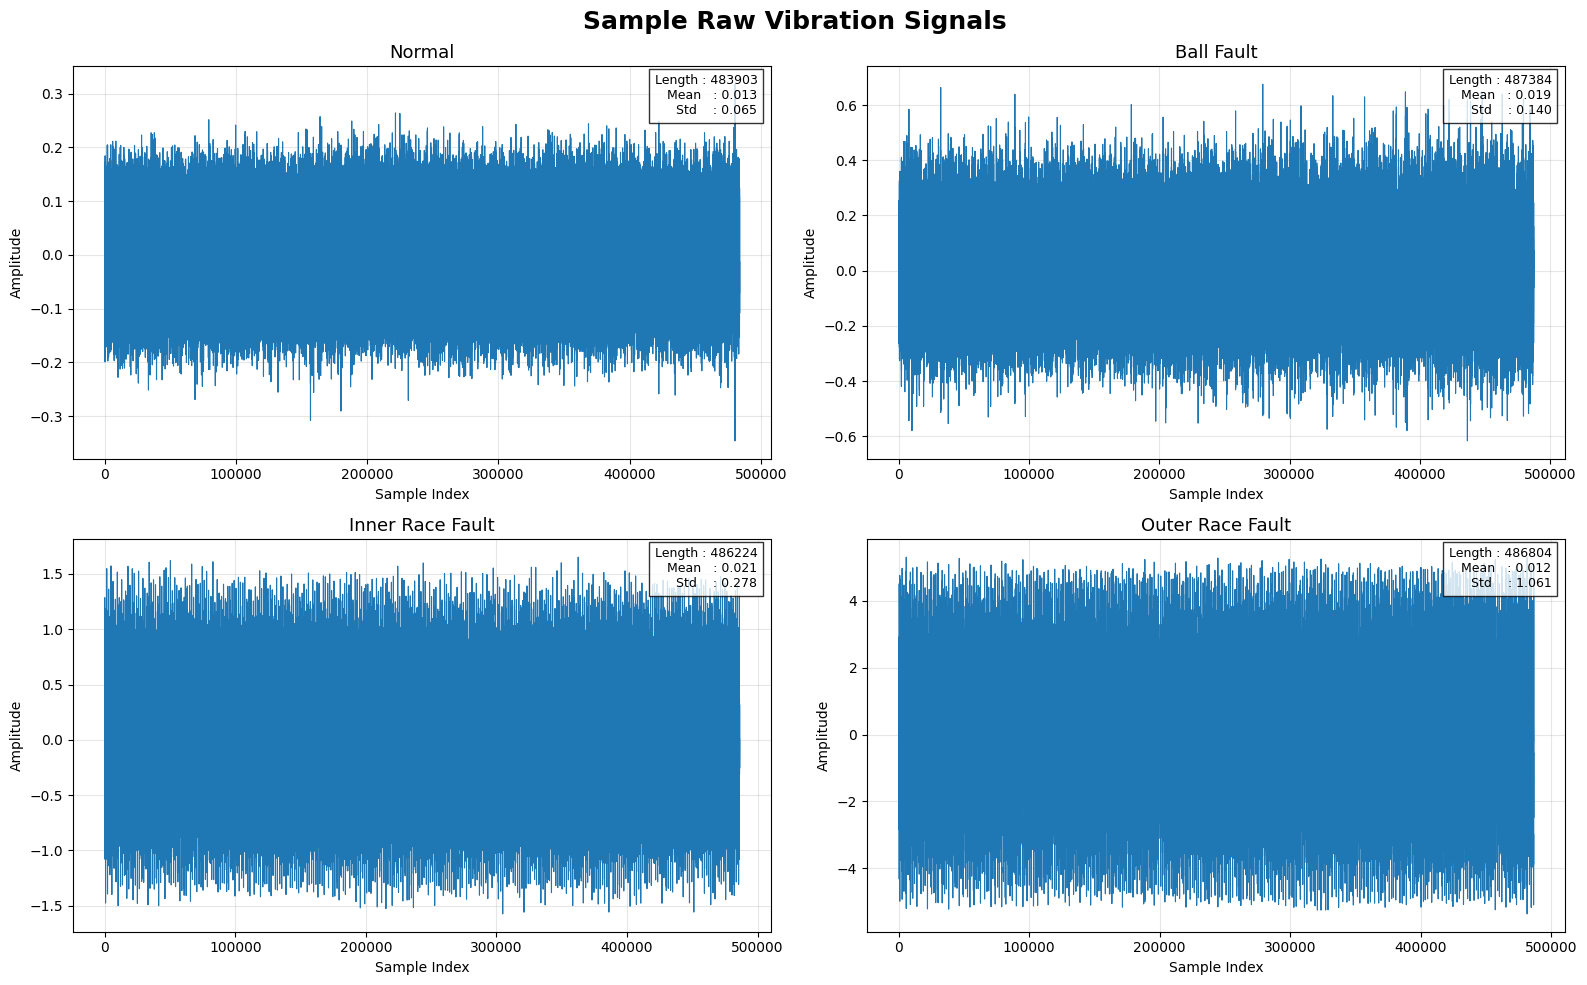


✅ Raw signal visualization completed.


In [9]:
# ==========================================================
# VISUALIZE RAW VIBRATION SIGNALS
# ==========================================================

print("=" * 70)
print("RAW SIGNAL VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sample Raw Vibration Signals", fontsize=18, fontweight="bold")

for class_id in range(NUM_CLASSES):

    ax = axes[class_id // 2, class_id % 2]

    indices = np.where(labels == class_id)[0]

    if len(indices) == 0:
        continue

    sample_idx = indices[0]

    signal = signals[sample_idx]

    ax.plot(signal, linewidth=0.8)

    ax.set_title(CLASS_NAMES[class_id], fontsize=13)

    ax.set_xlabel("Sample Index")

    ax.set_ylabel("Amplitude")

    ax.grid(alpha=0.3)

    stats = (
        f"Length : {len(signal)}\n"
        f"Mean   : {np.mean(signal):.3f}\n"
        f"Std    : {np.std(signal):.3f}"
    )

    ax.text(
        0.98,
        0.98,
        stats,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8)
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "raw_signals.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Raw signal visualization completed.")

In [18]:
# ==========================================================
# Guess Sampling Frequency
# ==========================================================

import numpy as np

largest = None
largest_key = None

for key, value in mat.items():

    if key.startswith("__"):
        continue

    if isinstance(value, np.ndarray):

        if largest is None or value.size > largest.size:

            largest = value
            largest_key = key

length = largest.size

print(f"Signal Variable : {largest_key}")
print(f"Signal Length   : {length:,}")

if length > 300000:
    print("\nLikely Sampling Rate : 48 kHz")
elif length > 100000:
    print("\nLikely Sampling Rate : 12 kHz")
else:
    print("\nSampling rate cannot be inferred from length alone.")

Signal Variable : X098_DE_time
Signal Length   : 483,903

Likely Sampling Rate : 48 kHz


## SECTION 2: DATA PREPROCESSING & FEATURE ENGINEERING

In [19]:
import scipy.signal as sp_signal

def preprocess_signal(sig, sampling_rate=48000, lowcut=500, highcut=10000):
    """
    Preprocess bearing vibration signal:
    1. Bandpass filtering (remove noise)
    2. Normalization
    3. Optional envelope detection
    """

    # Flatten signal
    sig = np.asarray(sig).flatten()

    # 1. Bandpass filter
    nyquist = sampling_rate / 2
    low = lowcut / nyquist
    high = highcut / nyquist

    if high >= 1.0:
        high = 0.99
    if low >= high:
        low = high - 0.1

    # CHANGE: use sp_signal instead of signal
    b, a = sp_signal.butter(4, [low, high], btype='bandpass')
    filtered = sp_signal.filtfilt(b, a, sig)

    # 2. Normalization
    normalized = (filtered - np.mean(filtered)) / (np.std(filtered) + 1e-8)

    return normalized


def extract_time_domain_features(signal):
    """
    Extract time-domain features from vibration signal
    """
    features = {
        'mean': np.mean(signal),
        'std': np.std(signal),
        'peak': np.max(np.abs(signal)),
        'rms': np.sqrt(np.mean(signal**2)),
        'skewness': (np.mean((signal - np.mean(signal))**3)) / (np.std(signal)**3 + 1e-8),
        'kurtosis': (np.mean((signal - np.mean(signal))**4)) / (np.std(signal)**4 + 1e-8),
        'crest_factor': np.max(np.abs(signal)) / (np.sqrt(np.mean(signal**2)) + 1e-8),
    }
    return features


# CHANGE: sampling_rate = 48000
def extract_frequency_domain_features(signal, sampling_rate=48000):
    """
    Extract frequency-domain features using FFT
    """

    fft = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal), 1/sampling_rate)

    positive_idx = freqs > 0
    fft_pos = fft[positive_idx]
    freqs_pos = freqs[positive_idx]

    dominant_freq_idx = np.argmax(fft_pos)

    features = {
        'freq_peak': freqs_pos[dominant_freq_idx],
        'freq_energy': np.sum(fft_pos**2),
        'freq_entropy': -np.sum((fft_pos / np.sum(fft_pos)) *
                                np.log(fft_pos / np.sum(fft_pos) + 1e-8)),
    }

    return features


print("✅ Preprocessing functions defined")

✅ Preprocessing functions defined


In [20]:
# ==========================================================
# APPLY PREPROCESSING
# ==========================================================

print("\n🔧 APPLYING PREPROCESSING\n")

X_processed = []

print(f"Processing {len(signals)} signals...\n")

for i, sig in enumerate(signals):

    processed = preprocess_signal(sig)

    X_processed.append(processed)

    if (i + 1) % max(1, len(signals)//10) == 0 or i == len(signals)-1:
        print(f"Processed {i+1}/{len(signals)}")

print("\n✅ Preprocessing complete")

all_values = np.concatenate(X_processed)

print(f"Total processed signals : {len(X_processed)}")
print(f"Minimum amplitude       : {all_values.min():.4f}")
print(f"Maximum amplitude       : {all_values.max():.4f}")
print(f"Mean                    : {all_values.mean():.4f}")
print(f"Standard Deviation      : {all_values.std():.4f}")


🔧 APPLYING PREPROCESSING

Processing 10 signals...

Processed 1/10
Processed 2/10
Processed 3/10
Processed 4/10
Processed 5/10
Processed 6/10
Processed 7/10
Processed 8/10
Processed 9/10
Processed 10/10

✅ Preprocessing complete
Total processed signals : 10
Minimum amplitude       : -17.0910
Maximum amplitude       : 18.2673
Mean                    : 0.0000
Standard Deviation      : 1.0000


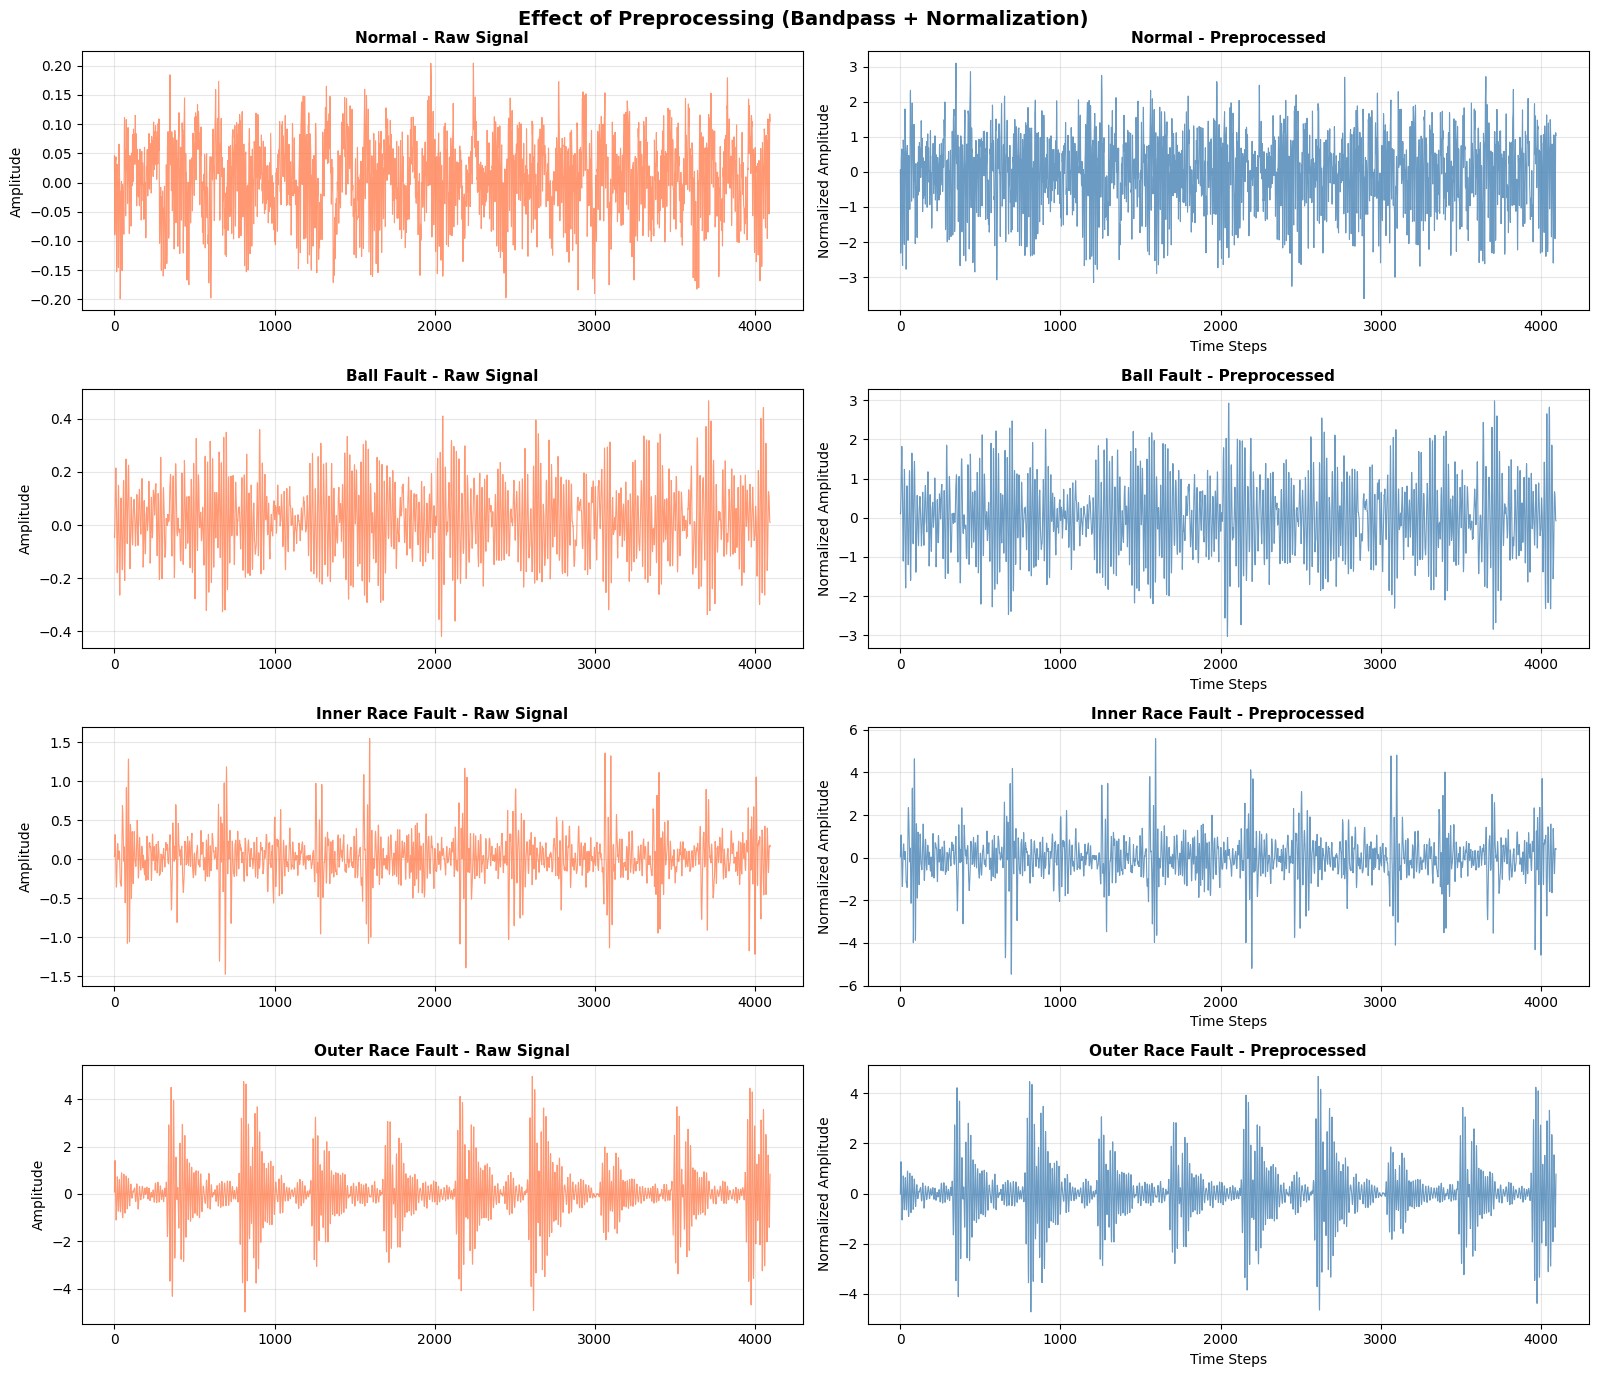

✅ Preprocessing visualization saved!


In [26]:
# Visualize preprocessing effect
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Effect of Preprocessing (Bandpass + Normalization)', fontsize=14, fontweight='bold')

for class_id in range(NUM_CLASSES):
    ax_raw = axes[class_id, 0]
    ax_proc = axes[class_id, 1]

    class_indices = np.where(labels == class_id)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]

        signal_raw = signals[sample_idx]
        signal_processed = X_processed[sample_idx]

        # Raw signal
        # Raw signal
        ax_raw.plot(signal_raw[:4096], linewidth=0.8, color='coral', alpha=0.8)
        ax_raw.set_title(f'{CLASS_NAMES[class_id]} - Raw Signal', fontsize=11, fontweight='bold')
        ax_raw.set_ylabel('Amplitude', fontsize=10)
        ax_raw.grid(True, alpha=0.3)

        # Processed signal
        ax_proc.plot(signal_processed[:4096], linewidth=0.8, color='steelblue', alpha=0.8)
        ax_proc.set_title(f'{CLASS_NAMES[class_id]} - Preprocessed', fontsize=11, fontweight='bold')
        ax_proc.set_xlabel('Time Steps', fontsize=10)
        ax_proc.set_ylabel('Normalized Amplitude', fontsize=10)
        ax_proc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "preprocessing_effect.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("✅ Preprocessing visualization saved!")

In [27]:
WINDOW_SIZE = 2048
OVERLAP = 1024          # 50% overlap
STEP_SIZE = WINDOW_SIZE - OVERLAP

print("\n📦 SLIDING WINDOW SEGMENTATION\n")
print(f"Window Size : {WINDOW_SIZE}")
print(f"Overlap     : {OVERLAP}")
print(f"Step Size   : {STEP_SIZE}")

X_data = []
y_data = []

for signal, label in zip(X_processed, labels):

    signal = np.asarray(signal).flatten()

    for start in range(0, len(signal) - WINDOW_SIZE + 1, STEP_SIZE):

        window = signal[start:start + WINDOW_SIZE]

        X_data.append(window)
        y_data.append(label)

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data)

print("\n✅ Segmentation Complete")
print(f"Total Windows : {len(X_data)}")
print(f"Window Shape  : {X_data.shape}")
print(f"Labels Shape  : {y_data.shape}")


📦 SLIDING WINDOW SEGMENTATION

Window Size : 2048
Overlap     : 1024
Step Size   : 1024

✅ Segmentation Complete
Total Windows : 5213
Window Shape  : (5213, 2048)
Labels Shape  : (5213,)


In [28]:
# ==========================================================
# DATASET STATISTICS AFTER SEGMENTATION
# ==========================================================

print("\n📊 DATASET AFTER SEGMENTATION")
print("="*60)

unique_labels, counts = np.unique(y_data, return_counts=True)

for label, count in zip(unique_labels, counts):

    percentage = (count / len(y_data)) * 100

    print(f"{CLASS_NAMES[label]:20s} : {count:6d} ({percentage:5.2f}%)")

print("-"*60)
print(f"Total Samples : {len(y_data)}")


📊 DATASET AFTER SEGMENTATION
Normal               :    471 ( 9.04%)
Ball Fault           :   1421 (27.26%)
Inner Race Fault     :   1899 (36.43%)
Outer Race Fault     :   1422 (27.28%)
------------------------------------------------------------
Total Samples : 5213


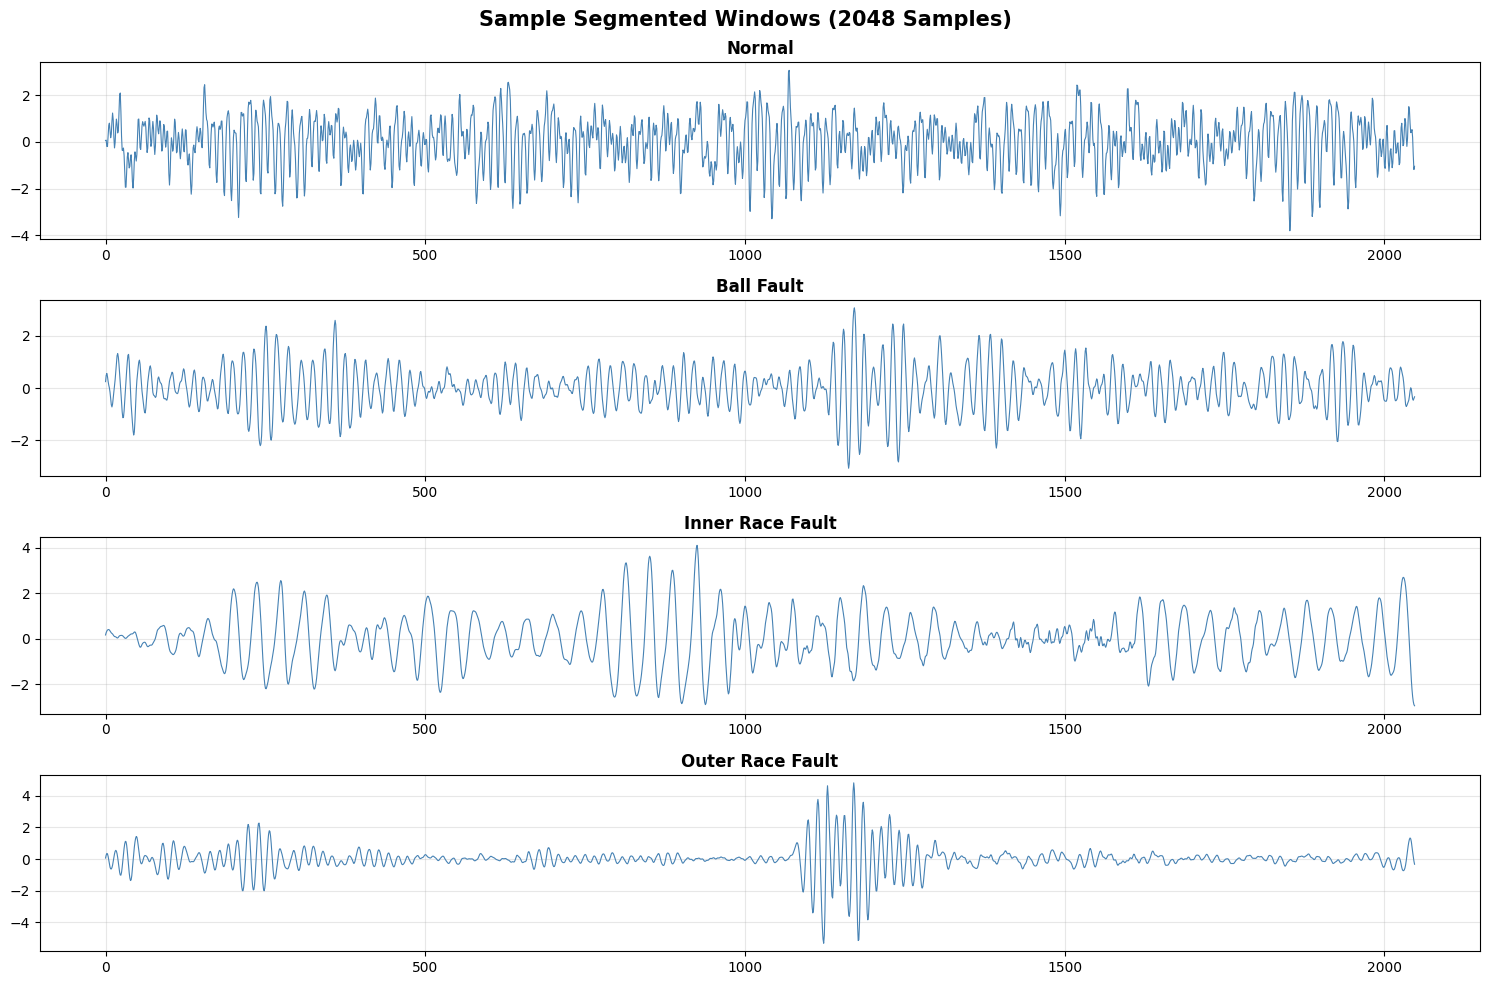

✅ Segmented signal visualization saved!


In [29]:
# ==========================================================
# VISUALIZE SEGMENTED WINDOWS
# ==========================================================

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

fig.suptitle(
    "Sample Segmented Windows (2048 Samples)",
    fontsize=15,
    fontweight="bold"
)

for class_id in range(NUM_CLASSES):

    indices = np.where(y_data == class_id)[0]

    sample_idx = np.random.choice(indices)

    axes[class_id].plot(
        X_data[sample_idx],
        color="steelblue",
        linewidth=0.8
    )

    axes[class_id].set_title(
        CLASS_NAMES[class_id],
        fontweight="bold"
    )

    axes[class_id].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "segmented_windows.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Segmented signal visualization saved!")

In [30]:
print("\n📊 TRAIN / VALIDATION / TEST SPLIT\n")
print("="*60)

# 70% Train | 15% Validation | 15% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X_data,
    y_data,
    test_size=0.30,
    random_state=42,
    stratify=y_data,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
    shuffle=True
)

print("✅ Dataset Split Complete\n")

print(f"Training Set   : {X_train.shape}")
print(f"Validation Set : {X_val.shape}")
print(f"Test Set       : {X_test.shape}")

print("\nSplit Ratio")
print("-"*40)
print(f"Train      : {len(X_train)} ({100*len(X_train)/len(X_data):.1f}%)")
print(f"Validation : {len(X_val)} ({100*len(X_val)/len(X_data):.1f}%)")
print(f"Test       : {len(X_test)} ({100*len(X_test)/len(X_data):.1f}%)")
print(f"Total      : {len(X_train)+len(X_val)+len(X_test)}")


📊 TRAIN / VALIDATION / TEST SPLIT

✅ Dataset Split Complete

Training Set   : (3649, 2048)
Validation Set : (782, 2048)
Test Set       : (782, 2048)

Split Ratio
----------------------------------------
Train      : 3649 (70.0%)
Validation : 782 (15.0%)
Test       : 782 (15.0%)
Total      : 5213


In [31]:
# ==========================================================
# VERIFY STRATIFIED SPLIT
# ==========================================================

def print_distribution(name, labels):

    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name}")
    print("-"*45)

    for cls, cnt in zip(unique, counts):

        percentage = cnt / len(labels) * 100

        print(f"{CLASS_NAMES[cls]:20s}: {cnt:5d} ({percentage:5.2f}%)")


print_distribution("Training Set", y_train)
print_distribution("Validation Set", y_val)
print_distribution("Test Set", y_test)


Training Set
---------------------------------------------
Normal              :   330 ( 9.04%)
Ball Fault          :   995 (27.27%)
Inner Race Fault    :  1329 (36.42%)
Outer Race Fault    :   995 (27.27%)

Validation Set
---------------------------------------------
Normal              :    70 ( 8.95%)
Ball Fault          :   213 (27.24%)
Inner Race Fault    :   285 (36.45%)
Outer Race Fault    :   214 (27.37%)

Test Set
---------------------------------------------
Normal              :    71 ( 9.08%)
Ball Fault          :   213 (27.24%)
Inner Race Fault    :   285 (36.45%)
Outer Race Fault    :   213 (27.24%)


In [32]:
print("\n📏 FEATURE STANDARDIZATION\n")
print("="*60)

# StandardScaler learns only from training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("✅ Feature standardization completed.\n")

print(f"Training Shape   : {X_train_scaled.shape}")
print(f"Validation Shape : {X_val_scaled.shape}")
print(f"Test Shape       : {X_test_scaled.shape}")

print("\nTraining Statistics")
print("-"*40)
print(f"Mean : {X_train_scaled.mean():.6f}")
print(f"Std  : {X_train_scaled.std():.6f}")


📏 FEATURE STANDARDIZATION

✅ Feature standardization completed.

Training Shape   : (3649, 2048)
Validation Shape : (782, 2048)
Test Shape       : (782, 2048)

Training Statistics
----------------------------------------
Mean : -0.000000
Std  : 1.000000


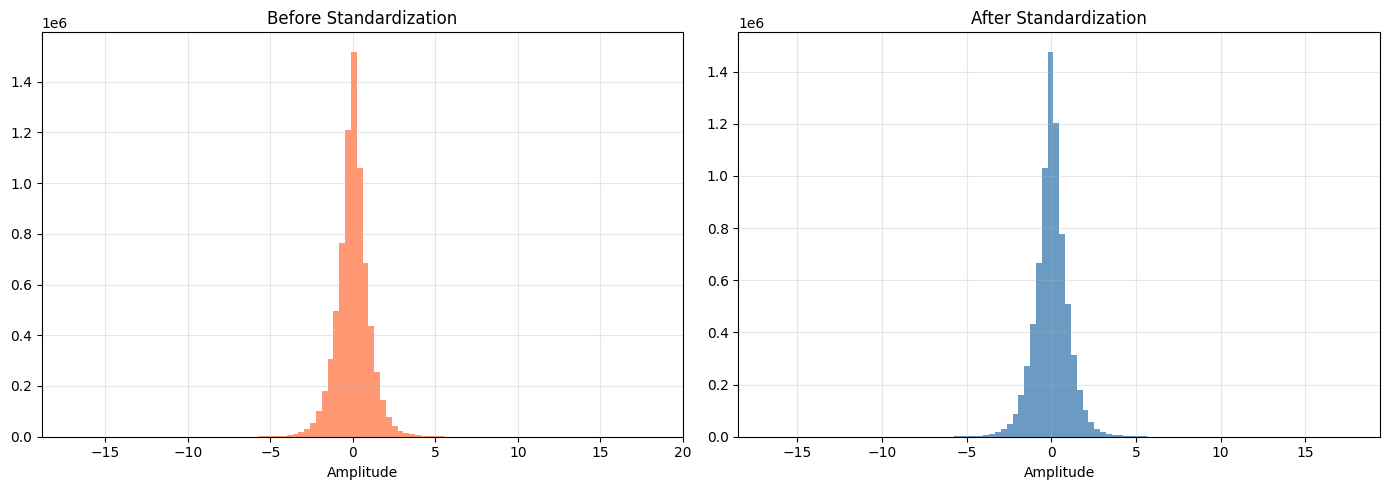

✅ Standardization visualization saved!


In [33]:
# ==========================================================
# VERIFY STANDARDIZATION
# ==========================================================

fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].hist(
    X_train.flatten(),
    bins=100,
    color="coral",
    alpha=0.8
)

axes[0].set_title("Before Standardization")
axes[0].set_xlabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].hist(
    X_train_scaled.flatten(),
    bins=100,
    color="steelblue",
    alpha=0.8
)

axes[1].set_title("After Standardization")
axes[1].set_xlabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR,"standardization_effect.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Standardization visualization saved!")

## SECTION 3: CLASS IMBALANCE HANDLING (SMOTE)

In [37]:
from imblearn.over_sampling import SMOTE

print("\n⚖️  CLASS IMBALANCE HANDLING WITH SMOTE\n")
print("-"*60)

X_for_smote = X_train_scaled

print("\n🔍 BEFORE SMOTE")
print("-"*60)

unique_before, counts_before = np.unique(y_train, return_counts=True)

for label, count in zip(unique_before, counts_before):

    percentage = count / len(y_train) * 100

    print(f"{CLASS_NAMES[label]:20s}: {count:5d} ({percentage:5.2f}%)")

print(f"\nTotal Training Samples : {len(y_train)}")
print(f"Imbalance Ratio        : {counts_before.max()/counts_before.min():.2f}x")

print("\n🔄 Applying SMOTE...")

try:

    smote = SMOTE(
        random_state=42,
        k_neighbors=3
    )

    X_resampled, y_resampled = smote.fit_resample(
        X_for_smote,
        y_train
    )

    print("\n✅ SMOTE completed successfully!")

except Exception as e:

    print(f"\n⚠️ SMOTE failed: {e}")

    print("\nUsing original training data...")

    X_resampled = X_train_scaled.copy()
    y_resampled = y_train.copy()

print("\n📊 AFTER SMOTE")
print("-"*60)

unique_after, counts_after = np.unique(
    y_resampled,
    return_counts=True
)

for label, count in zip(unique_after, counts_after):

    percentage = count / len(y_resampled) * 100

    print(f"{CLASS_NAMES[label]:20s}: {count:5d} ({percentage:5.2f}%)")

print(f"\nTotal Samples : {len(y_resampled)}")

print(f"Improvement   : {len(y_train)} → {len(y_resampled)}")


⚖️  CLASS IMBALANCE HANDLING WITH SMOTE

------------------------------------------------------------

🔍 BEFORE SMOTE
------------------------------------------------------------
Normal              :   330 ( 9.04%)
Ball Fault          :   995 (27.27%)
Inner Race Fault    :  1329 (36.42%)
Outer Race Fault    :   995 (27.27%)

Total Training Samples : 3649
Imbalance Ratio        : 4.03x

🔄 Applying SMOTE...

✅ SMOTE completed successfully!

📊 AFTER SMOTE
------------------------------------------------------------
Normal              :  1329 (25.00%)
Ball Fault          :  1329 (25.00%)
Inner Race Fault    :  1329 (25.00%)
Outer Race Fault    :  1329 (25.00%)

Total Samples : 5316
Improvement   : 3649 → 5316


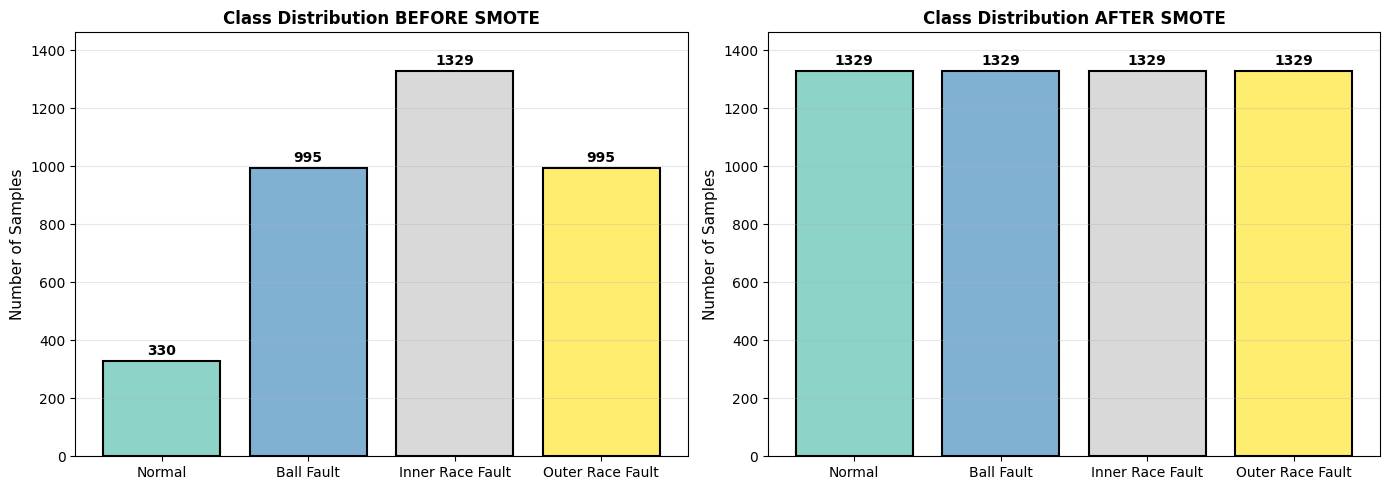

✅ Class distribution visualization saved!


In [38]:
# Visualize class distribution before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
ax1 = axes[0]
unique_before, counts_before = np.unique(y_train, return_counts=True)

colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))

ax1.bar(
    [CLASS_NAMES[i] for i in unique_before],
    counts_before,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

ax1.set_title('Class Distribution BEFORE SMOTE',
              fontsize=12,
              fontweight='bold')

ax1.set_ylabel('Number of Samples', fontsize=11)

ax1.set_ylim([0, counts_after.max() * 1.1])

for i, (label, count) in enumerate(zip(unique_before, counts_before)):
    ax1.text(i, count + 20, str(count),
             ha='center',
             fontsize=10,
             fontweight='bold')

ax1.grid(True, alpha=0.3, axis='y')

# After SMOTE
ax2 = axes[1]

unique_after, counts_after = np.unique(
    y_resampled,
    return_counts=True
)

ax2.bar(
    [CLASS_NAMES[i] for i in unique_after],
    counts_after,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

ax2.set_title('Class Distribution AFTER SMOTE',
              fontsize=12,
              fontweight='bold')

ax2.set_ylabel('Number of Samples', fontsize=11)

ax2.set_ylim([0, counts_after.max() * 1.1])

for i, (label, count) in enumerate(zip(unique_after, counts_after)):
    ax2.text(i, count + 20, str(count),
             ha='center',
             fontsize=10,
             fontweight='bold')

ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "smote_effect.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Class distribution visualization saved!")

In [39]:
# Convert to PyTorch tensors
print("\n🔄 Converting to PyTorch tensors...")

X_train_tensor = torch.from_numpy(X_resampled).float().unsqueeze(1).to(device)
y_train_tensor = torch.from_numpy(y_resampled).long().to(device)

X_val_tensor = torch.from_numpy(X_val_scaled).float().unsqueeze(1).to(device)
y_val_tensor = torch.from_numpy(y_val).long().to(device)

X_test_tensor = torch.from_numpy(X_test_scaled).float().unsqueeze(1).to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

# Create DataLoaders
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data loaders created")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")
print(X_resampled.shape)
print(y_resampled.shape)

print(X_val_scaled.shape)
print(y_val.shape)

print(X_test_scaled.shape)
print(y_test.shape)


🔄 Converting to PyTorch tensors...
✅ Data loaders created
   Training batches: 167
   Validation batches: 25
   Test batches: 25
(5316, 2048)
(5316,)
(782, 2048)
(782,)
(782, 2048)
(782,)


## SECTION 4: MODEL ARCHITECTURE (AttentionBearingNet)

In [40]:
class AttentionBearingNet(nn.Module):
    """
    AttentionBearingNet: CNN + Bidirectional LSTM + MultiheadAttention

    Architecture:
    1. CNN Feature Extraction (multi-scale kernels)
    2. Bidirectional LSTM (temporal dependencies)
    3. MultiheadAttention (temporal focus)
    4. Fusion Layer (concatenate both branches)
    5. Classification Head + Uncertainty Head
    """

    def __init__(self, input_length=2048, num_classes=4):
        super(AttentionBearingNet, self).__init__()

        # CNN Feature Extraction
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=7, padding=3)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # Calculate size after convolutions
        self.cnn_out_length = input_length // 4

        # LSTM Branch
        self.lstm = nn.LSTM(
    input_size=128,
    hidden_size=64,
    num_layers=2,
    batch_first=True,
    bidirectional=True,
    dropout=0.3
)
        self.lstm_hidden_size = 64 * 2  # bidirectional

        # Attention Branch
        self.attention = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=4,
            batch_first=True,
            dropout=0.1
        )

        # Fusion Layer
        self.fusion_fc1 = nn.Linear(128 + self.lstm_hidden_size, 128)
        self.fusion_dropout = nn.Dropout(0.3)

        # Classification head
        self.fc_class = nn.Linear(128, num_classes)

        # Uncertainty head
        self.fc_uncertainty = nn.Linear(128, 1)

    def forward(self, x):
        # x shape: (batch, 1, signal_length)

        # CNN feature extraction
        x_cnn = x.unsqueeze(1) if len(x.shape) == 2 else x
        x_cnn = F.relu(self.bn1(self.conv1(x_cnn)))
        x_cnn = F.relu(self.bn2(self.conv2(x_cnn)))
        x_cnn = self.pool1(x_cnn)
        x_cnn = F.relu(self.bn3(self.conv3(x_cnn)))
        x_cnn = self.pool2(x_cnn)

        # x_cnn shape: (batch, 128, cnn_out_length)

        # Transpose for LSTM and Attention
        x_seq = x_cnn.transpose(1, 2)  # (batch, cnn_out_length, 128)

        # LSTM branch
        lstm_out, _ = self.lstm(x_seq)
        lstm_feature = lstm_out[:, -1, :]  # Take last output

        # Attention branch (self-attention over time steps)
        attn_out, attn_weights = self.attention(x_seq, x_seq, x_seq)
        attn_feature = attn_out.mean(dim=1)  # Average over time steps

        # Store attention weights for visualization later
        self.last_attention_weights = attn_weights

        # Fusion
        fused = torch.cat([attn_feature, lstm_feature], dim=1)  # (batch, 128+128)
        fused = F.relu(self.fusion_fc1(fused))
        fused = self.fusion_dropout(fused)

        # Classification
        logits = self.fc_class(fused)

        # Uncertainty
        uncertainty = torch.sigmoid(self.fc_uncertainty(fused))

        return logits, uncertainty, attn_weights

print("✅ AttentionBearingNet model defined")

# Initialize model
model = AttentionBearingNet(input_length=X_train_scaled.shape[1], num_classes=NUM_CLASSES)
model.to(device)

print(f"\n🏗️  Model Summary:")
print(f"{'-'*60}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nDevice: {next(model.parameters()).device}")

✅ AttentionBearingNet model defined

🏗️  Model Summary:
------------------------------------------------------------
Total parameters: 366,597
Trainable parameters: 366,597

Device: cuda:0


In [41]:
# Test forward pass
print("\n🧪 Testing forward pass...")

with torch.no_grad():
    batch_x, batch_y = next(iter(train_loader))
    batch_x = batch_x.to(device)
    logits, uncertainty, attn_weights = model(batch_x)

    print(f"Input shape: {batch_x.shape}")
    print(f"Output logits shape: {logits.shape}")
    print(f"Uncertainty shape: {uncertainty.shape}")
    print(f"Attention weights shape: {attn_weights.shape}")
    print(f"\n✅ Forward pass successful!")


🧪 Testing forward pass...
Input shape: torch.Size([32, 1, 2048])
Output logits shape: torch.Size([32, 4])
Uncertainty shape: torch.Size([32, 1])
Attention weights shape: torch.Size([32, 512, 512])

✅ Forward pass successful!


In [42]:
print("\n📋 MODEL CONFIGURATION")
print("-" * 60)

print(f"Input Length     : {X_train_tensor.shape[-1]}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Batch Size       : {BATCH_SIZE}")
print(f"CNN Channels     : 32 → 64 → 128")
print(f"LSTM Hidden Size : 64 × 2 (Bidirectional)")
print(f"Attention Heads  : 4")
print(f"Total Parameters : {total_params:,}")


📋 MODEL CONFIGURATION
------------------------------------------------------------
Input Length     : 2048
Number of Classes: 4
Batch Size       : 32
CNN Channels     : 32 → 64 → 128
LSTM Hidden Size : 64 × 2 (Bidirectional)
Attention Heads  : 4
Total Parameters : 366,597


## SECTION 5: MODEL TRAINING

In [44]:
# Training setup
print("\n🚀 SETTING UP TRAINING\n")

# Loss function with class weights to handle any remaining imbalance
class_weights = torch.tensor([1.0 / count for count in np.bincount(y_resampled)], dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum()  # Normalize

criterion_class = nn.CrossEntropyLoss()
criterion_uncertainty = nn.BCELoss()  # Binary cross-entropy for uncertainty

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

print(f"✅ Training setup complete")
print(f"   Criterion: CrossEntropyLoss (with class weights)")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Device: {device}")


🚀 SETTING UP TRAINING

✅ Training setup complete
   Criterion: CrossEntropyLoss (with class weights)
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau
   Device: cuda


In [45]:
def train_epoch(model, train_loader, criterion_class, criterion_uncertainty, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()

        logits, uncertainty, _ = model(batch_x)

        # Combined loss
        loss_class = criterion_class(logits, batch_y)
        loss_uncertainty = criterion_uncertainty(uncertainty, torch.ones_like(uncertainty) * 0.5)
        loss = loss_class + 0.1 * loss_uncertainty

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(logits, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    return avg_loss, accuracy

def validate(model, val_loader, criterion_class, criterion_uncertainty, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            logits, uncertainty, _ = model(batch_x)

            loss_class = criterion_class(logits, batch_y)
            loss_uncertainty = criterion_uncertainty(uncertainty, torch.ones_like(uncertainty) * 0.5)
            loss = loss_class + 0.1 * loss_uncertainty

            total_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

print("✅ Training functions defined")

✅ Training functions defined


In [46]:
# Training loop
print("\n" + "="*70)
print("🎯 STARTING TRAINING".center(70))
print("="*70)

NUM_EPOCHS = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion_class, criterion_uncertainty, optimizer, device
    )

    val_loss, val_acc, _, _ = validate(
        model, val_loader, criterion_class, criterion_uncertainty, device
    )

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), '/content/best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹️  Early stopping at epoch {epoch+1}")
            break

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\n✅ Training complete!")
print(f"   Total epochs: {len(train_losses)}")
print(f"   Best validation loss: {min(val_losses):.4f}")
print(f"   Best validation accuracy: {max(val_accuracies):.4f}")


                         🎯 STARTING TRAINING                          
Epoch  10 | Train Loss: 0.1669 | Train Acc: 0.9624 | Val Loss: 0.1547 | Val Acc: 0.9680
Epoch  20 | Train Loss: 0.1349 | Train Acc: 0.9750 | Val Loss: 0.1402 | Val Acc: 0.9680
Epoch  30 | Train Loss: 0.0932 | Train Acc: 0.9910 | Val Loss: 0.2770 | Val Acc: 0.9412

⏹️  Early stopping at epoch 40

✅ Training complete!
   Total epochs: 40
   Best validation loss: 0.1257
   Best validation accuracy: 0.9783


In [47]:
from google.colab import files

files.download('/content/best_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": len(train_losses),
    "best_val_loss": best_val_loss,
    "num_classes": NUM_CLASSES,
    "window_size": 2048
}, "AttentionBearingNet_checkpoint.pth")

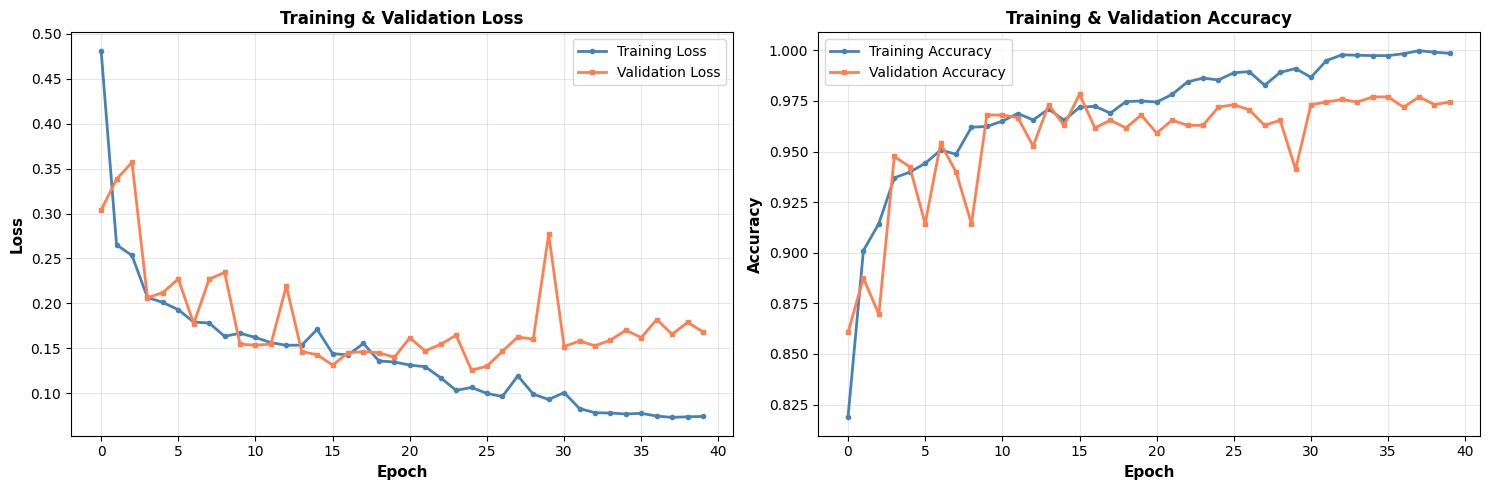

✅ Training curves saved!


In [49]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1 = axes[0]
ax1.plot(train_losses, label='Training Loss', linewidth=2, color='steelblue', marker='o', markersize=3)
ax1.plot(val_losses, label='Validation Loss', linewidth=2, color='coral', marker='s', markersize=3)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2 = axes[1]
ax2.plot(train_accuracies, label='Training Accuracy', linewidth=2, color='steelblue', marker='o', markersize=3)
ax2.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='coral', marker='s', markersize=3)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved!")

## SECTION 6: MODEL EVALUATION & METRICS

In [50]:
# Load best model
print("\n📦 Loading best model...")

model.load_state_dict(
    torch.load("/content/best_model.pth", map_location=device)
)

model.eval()

print("✅ Best model loaded")


📦 Loading best model...
✅ Best model loaded


In [52]:
# Evaluate on test set
print("\n🧪 EVALUATING ON TEST SET\n")

all_preds = []
all_probs = []
all_labels = []
all_uncertainties = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits, uncertainty, _ = model(batch_x)

        probs = F.softmax(logits, dim=1)
        _, predicted = torch.max(logits, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch_y.detach().cpu().numpy())
        all_uncertainties.extend(uncertainty.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)
y_probs = np.array(all_probs)
y_uncertainty = np.array(all_uncertainties).flatten()

print(f"✅ Predictions generated")
print(f"   Total samples: {len(y_true)}")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_probs.shape}")


🧪 EVALUATING ON TEST SET

✅ Predictions generated
   Total samples: 782
   Predictions shape: (782,)
   Probabilities shape: (782, 4)


In [53]:
# Compute metrics
print("\n" + "="*70)
print("📊 MODEL PERFORMANCE METRICS".center(70))
print("="*70)

# Overall metrics
overall_accuracy = accuracy_score(y_true, y_pred)
overall_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n🎯 OVERALL METRICS:")
print(f"{'-'*70}")
print(f"Accuracy:         {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"F1 Score (w):     {overall_f1:.4f}")

# Per-class metrics
print(f"\n📋 PER-CLASS METRICS:")
print(f"{'-'*70}")
print(f"{'Class':<20} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>10}")
print(f"{'-'*70}")

for class_id in range(NUM_CLASSES):
    class_mask = y_true == class_id
    class_support = class_mask.sum()

    tp = ((y_pred == class_id) & (y_true == class_id)).sum()
    fp = ((y_pred == class_id) & (y_true != class_id)).sum()
    fn = ((y_pred != class_id) & (y_true == class_id)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{CLASS_NAMES[class_id]:<20} {precision:>12.4f} {recall:>12.4f} {f1:>12.4f} {class_support:>10}")

print(f"{'-'*70}")


                     📊 MODEL PERFORMANCE METRICS                      

🎯 OVERALL METRICS:
----------------------------------------------------------------------
Accuracy:         0.9808 (98.08%)
F1 Score (w):     0.9808

📋 PER-CLASS METRICS:
----------------------------------------------------------------------
Class                   Precision       Recall     F1-Score    Support
----------------------------------------------------------------------
Normal                     1.0000       1.0000       1.0000         71
Ball Fault                 0.9626       0.9671       0.9649        213
Inner Race Fault           1.0000       1.0000       1.0000        285
Outer Race Fault           0.9670       0.9624       0.9647        213
----------------------------------------------------------------------


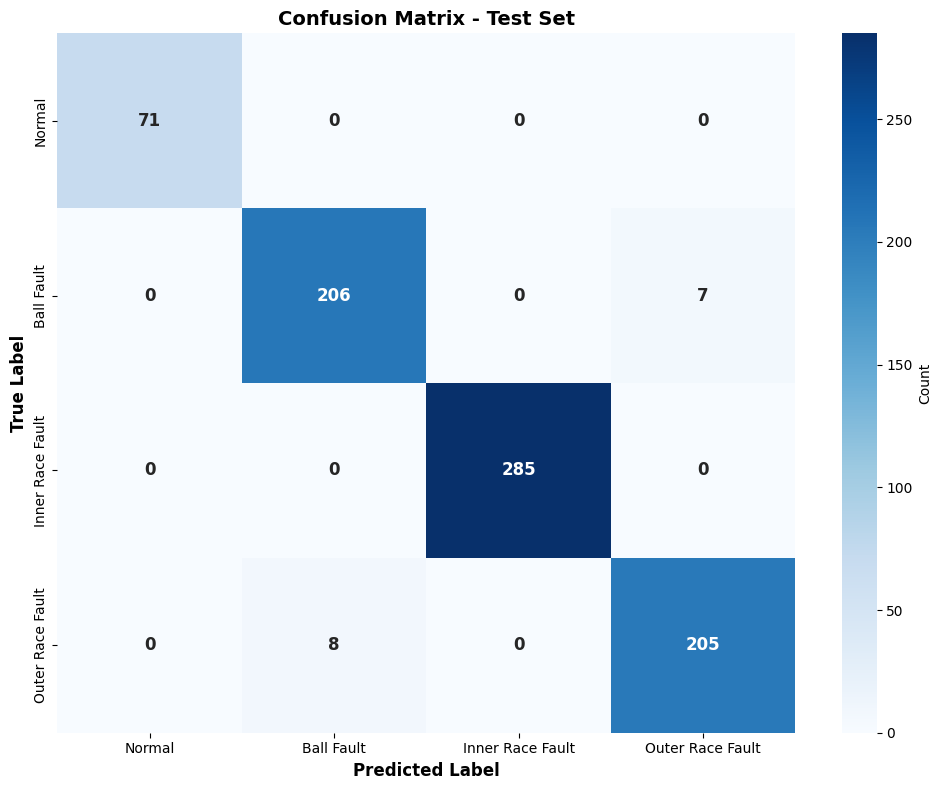

✅ Confusion matrix saved!


In [54]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved!")

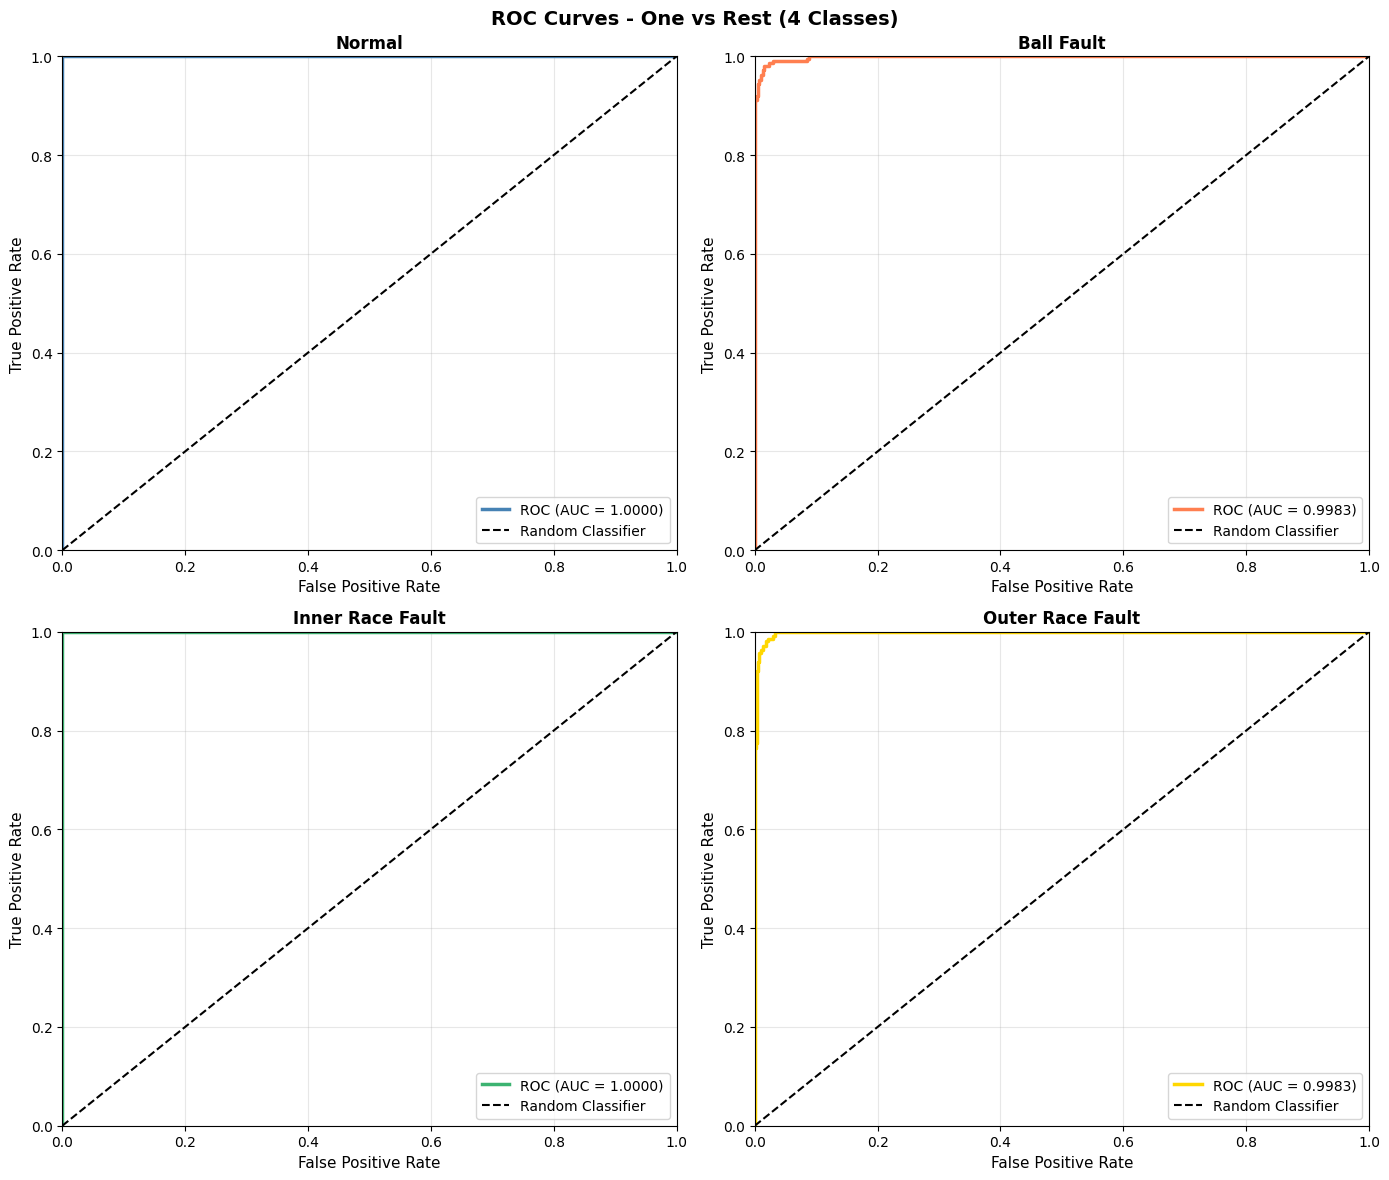


📈 ROC-AUC Scores:
   Normal              : 1.0000
   Ball Fault          : 0.9983
   Inner Race Fault    : 1.0000
   Outer Race Fault    : 0.9983
   Average ROC-AUC: 0.9992


In [55]:
# ROC curves (One-vs-Rest for multiclass)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('ROC Curves - One vs Rest (4 Classes)', fontsize=14, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'gold']
roc_aucs = []

for class_id in range(NUM_CLASSES):
    ax = axes[class_id // 2, class_id % 2]

    # One-vs-Rest binary classification
    y_true_binary = (y_true == class_id).astype(int)
    y_probs_class = y_probs[:, class_id]

    fpr, tpr, _ = roc_curve(y_true_binary, y_probs_class)
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)

    ax.plot(fpr, tpr, color=colors[class_id], lw=2.5,
            label=f'ROC (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{CLASS_NAMES[class_id]}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 ROC-AUC Scores:")
for class_id, roc_auc in enumerate(roc_aucs):
    print(f"   {CLASS_NAMES[class_id]:<20s}: {roc_auc:.4f}")
print(f"   Average ROC-AUC: {np.mean(roc_aucs):.4f}")

In [56]:
from sklearn.metrics import classification_report

print("\nClassification Report")
print("-" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)


Classification Report
------------------------------------------------------------
                  precision    recall  f1-score   support

          Normal     1.0000    1.0000    1.0000        71
      Ball Fault     0.9626    0.9671    0.9649       213
Inner Race Fault     1.0000    1.0000    1.0000       285
Outer Race Fault     0.9670    0.9624    0.9647       213

        accuracy                         0.9808       782
       macro avg     0.9824    0.9824    0.9824       782
    weighted avg     0.9808    0.9808    0.9808       782



In [57]:
print("\n🔍 SAMPLE PREDICTIONS\n")

for class_id in range(NUM_CLASSES):

    indices = np.where(y_true == class_id)[0]

    found = False

    for idx in indices:

        if y_pred[idx] == class_id:

            print(f"\nSample Index : {idx}")
            print(f"True Label   : {CLASS_NAMES[y_true[idx]]}")
            print(f"Prediction   : {CLASS_NAMES[y_pred[idx]]}")
            print(f"Confidence   : {np.max(y_probs[idx]):.4f}")
            print(f"Uncertainty  : {y_uncertainty[idx]:.4f}")

            found = True
            break

    if not found:
        print(f"\nNo correctly classified sample found for {CLASS_NAMES[class_id]}")


🔍 SAMPLE PREDICTIONS


Sample Index : 6
True Label   : Normal
Prediction   : Normal
Confidence   : 1.0000
Uncertainty  : 0.5000

Sample Index : 1
True Label   : Ball Fault
Prediction   : Ball Fault
Confidence   : 1.0000
Uncertainty  : 0.5000

Sample Index : 0
True Label   : Inner Race Fault
Prediction   : Inner Race Fault
Confidence   : 1.0000
Uncertainty  : 0.4999

Sample Index : 2
True Label   : Outer Race Fault
Prediction   : Outer Race Fault
Confidence   : 0.9573
Uncertainty  : 0.4999


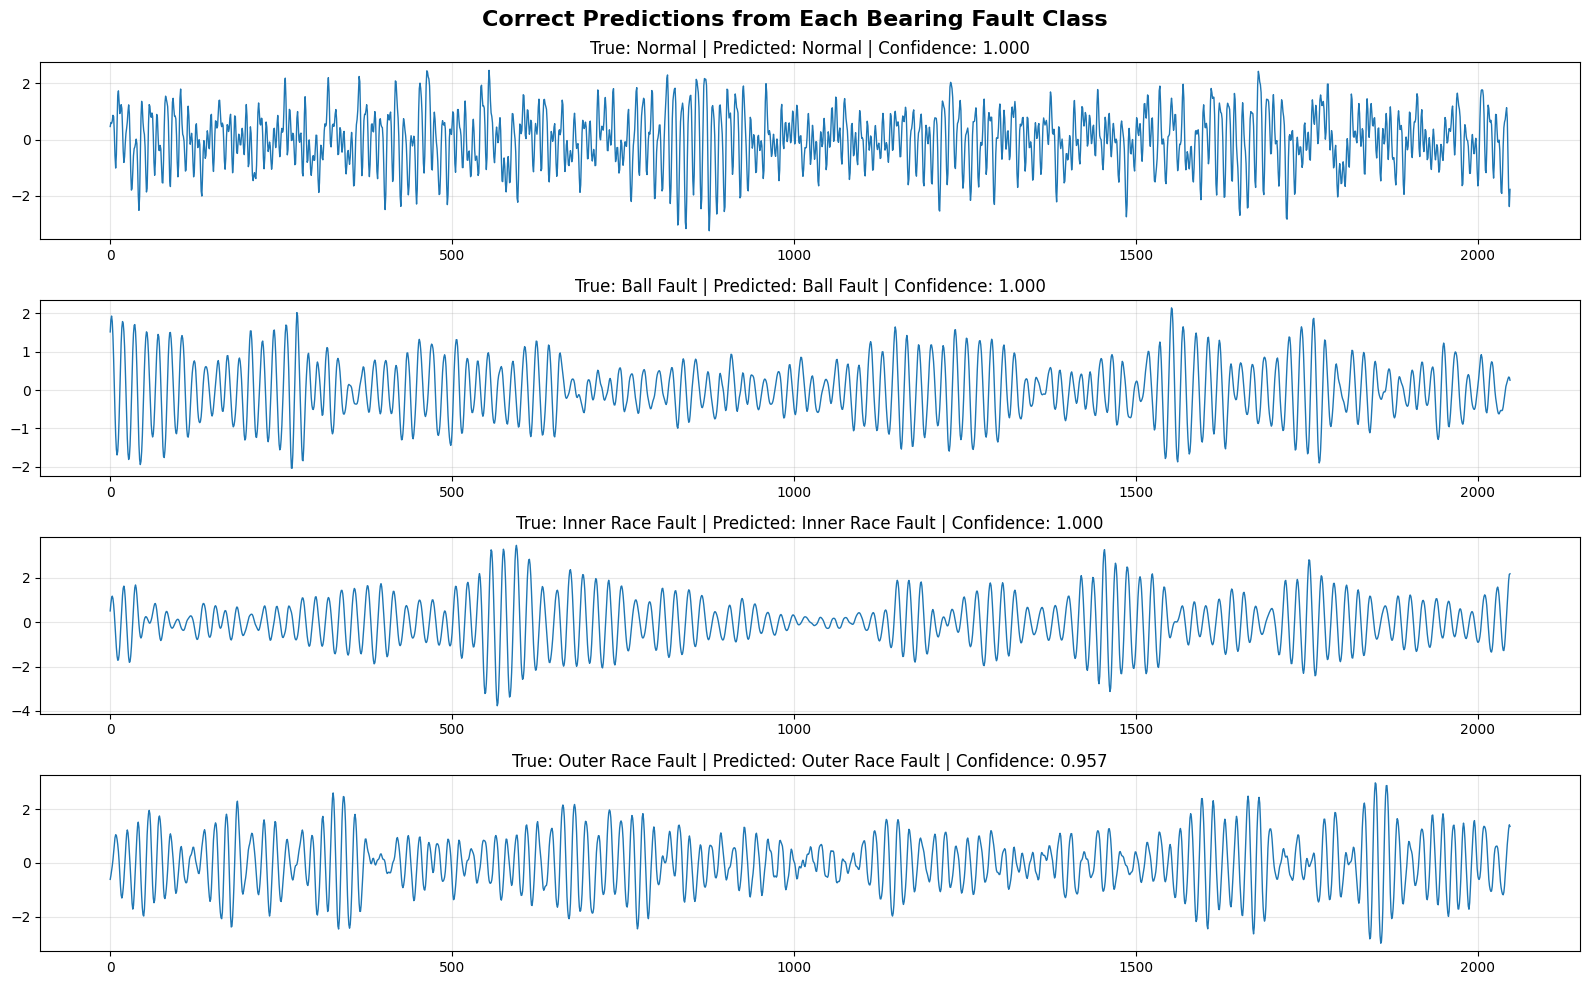

In [58]:
fig, axes = plt.subplots(4, 1, figsize=(16,10))

fig.suptitle(
    "Correct Predictions from Each Bearing Fault Class",
    fontsize=16,
    fontweight="bold"
)

for class_id in range(NUM_CLASSES):

    indices = np.where(y_true == class_id)[0]

    for idx in indices:

        if y_pred[idx] == class_id:

            axes[class_id].plot(
                X_test_scaled[idx],
                linewidth=1
            )

            axes[class_id].set_title(
                f"True: {CLASS_NAMES[class_id]} | "
                f"Predicted: {CLASS_NAMES[y_pred[idx]]} | "
                f"Confidence: {np.max(y_probs[idx]):.3f}"
            )

            axes[class_id].grid(alpha=0.3)

            break

plt.tight_layout()
plt.show()

## SECTION 7: EXPLAINABILITY (SHAP + ATTENTION + SALIENCY)

In [73]:
print("\n" + "="*70)
print("🔍 EXPLAINABILITY ANALYSIS".center(70))
print("="*70)

# Prepare background data for SHAP (use random samples from training set)
print("\n1️⃣ SHAP DeepExplainer (Global Feature Importance)")
print(f"{'--'*35}")

background_size = min(100, len(X_train_tensor))  # Use 100 random training samples
background_indices = np.random.choice(len(X_train_tensor), background_size, replace=False)
background_data = X_train_tensor[background_indices].to(device)

print(f"Background data size: {background_size} samples")
print(f"Preparing SHAP explainer...")

# Define model wrapper for SHAP
class SHAPModelWrapper(nn.Module):
    def __init__(self, model):
        super(SHAPModelWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        # Ensure input has channel dimension if it's missing (e.g., from numpy conversion before tensor)
        # However, X_train_tensor and X_test_tensor already have it.
        # The model's forward itself handles this as well.
        logits, _, _ = self.model(x)
        return logits

wrapped_model = SHAPModelWrapper(model).to(device) # Ensure wrapper is also on device

try:
    explainer = shap.DeepExplainer(wrapped_model, background_data)
    print(f"✅ SHAP explainer created")
except Exception as e:
    print(f"⚠️  SHAP creation error: {e}")
    explainer = None


                      🔍 EXPLAINABILITY ANALYSIS                       

1️⃣ SHAP DeepExplainer (Global Feature Importance)
----------------------------------------------------------------------
Background data size: 100 samples
Preparing SHAP explainer...
✅ SHAP explainer created


In [74]:
if explainer is not None:
    print(f"\n📊 Computing SHAP values (this may take 2-3 minutes)...")

    shap_values_all = {}
    sample_indices_shap = {}

    # Temporarily set model to train mode for SHAP gradient computation
    wrapped_model.train()

    for class_id in range(NUM_CLASSES):
        correct_idx = np.where(
            (y_test == class_id) &
            (y_pred == class_id)
        )[0]

        if len(correct_idx) > 0:
            sample_idx = correct_idx[0]
            sample_indices_shap[class_id] = sample_idx

            # Ensure sample_data is a PyTorch tensor on the device for DeepExplainer
            sample_data = X_test_tensor[sample_idx].unsqueeze(0).to(device)

            print(f"   Computing for {CLASS_NAMES[class_id]}...", end=" ")
            try:
                shap_vals = explainer.shap_values(
                     sample_data,
                     check_additivity=False
                 )
                shap_values_all[class_id] = shap_vals
                print(f"✅")
            except Exception as e:
                print(f"⚠️  Error: {e}")
                shap_values_all[class_id] = None
        else:
            print(f"   No correctly classified sample found for {CLASS_NAMES[class_id]}. Skipping SHAP computation.")
            shap_values_all[class_id] = None

    # Set model back to evaluation mode
    wrapped_model.eval()

    print(f"\n✅ SHAP computation complete")
else:
    print(f"⚠️  SHAP not available")
    shap_values_all = {}


📊 Computing SHAP values (this may take 2-3 minutes)...
   Computing for Normal... ✅
   Computing for Ball Fault... ✅
   Computing for Inner Race Fault... ✅
   Computing for Outer Race Fault... ✅

✅ SHAP computation complete


In [76]:
# 2. Attention Visualization
print(f"\n2️⃣ ATTENTION VISUALIZATION (Temporal Focus)")
print(f"{'-'*70}")

attention_weights_all = {}

with torch.no_grad():
    for class_id in range(NUM_CLASSES):
        class_indices = np.where(y_test == class_id)[0]
        if len(class_indices) > 0:
            sample_idx = class_indices[0]

            sample_x = X_test_tensor[sample_idx].unsqueeze(0).to(device)

            _, _, attn_weights = model(sample_x)
            attention_weights_all[class_id] = attn_weights.cpu().numpy()

print(f"✅ Attention weights extracted for {len(attention_weights_all)} classes")


2️⃣ ATTENTION VISUALIZATION (Temporal Focus)
----------------------------------------------------------------------
✅ Attention weights extracted for 4 classes


In [79]:
import torch.nn as nn
# 3. Temporal Saliency (Gradient-based sensitivity)
print(f"\n3️⃣ TEMPORAL SALIENCY (Gradient-Based Sensitivity)")
print(f"{'-'*70}")

saliency_maps = {}

# Create a separate model instance for saliency to avoid SHAP hooks interference
saliency_model = AttentionBearingNet(input_length=X_test_tensor.shape[2], num_classes=NUM_CLASSES)
saliency_model.load_state_dict(
    torch.load("/content/best_model.pth", map_location=device)
)
saliency_model.to(device)

# Temporarily set saliency_model to train mode for gradient computation
saliency_model.train()
with torch.enable_grad():
    for class_id in range(NUM_CLASSES):
        class_indices = np.where(y_test == class_id)[0]
        if len(class_indices) > 0:
            sample_idx = class_indices[0]

            sample_x = X_test_tensor[sample_idx].unsqueeze(0).to(device)
            sample_x.requires_grad = True

            logits, _, _ = saliency_model(sample_x) # Use saliency_model
            target_logit = logits[0, class_id]  # Target class

            # Compute gradients
            if sample_x.grad is not None:
                sample_x.grad.zero_()

            target_logit.backward()

            # Get gradient magnitude (saliency)
            saliency = torch.abs(sample_x.grad).squeeze().cpu().numpy()
            saliency_maps[class_id] = saliency

# Set saliency_model back to evaluation mode after saliency computation
saliency_model.eval()

print(f"✅ Saliency maps computed for {len(saliency_maps)} classes")


3️⃣ TEMPORAL SALIENCY (Gradient-Based Sensitivity)
----------------------------------------------------------------------
✅ Saliency maps computed for 4 classes


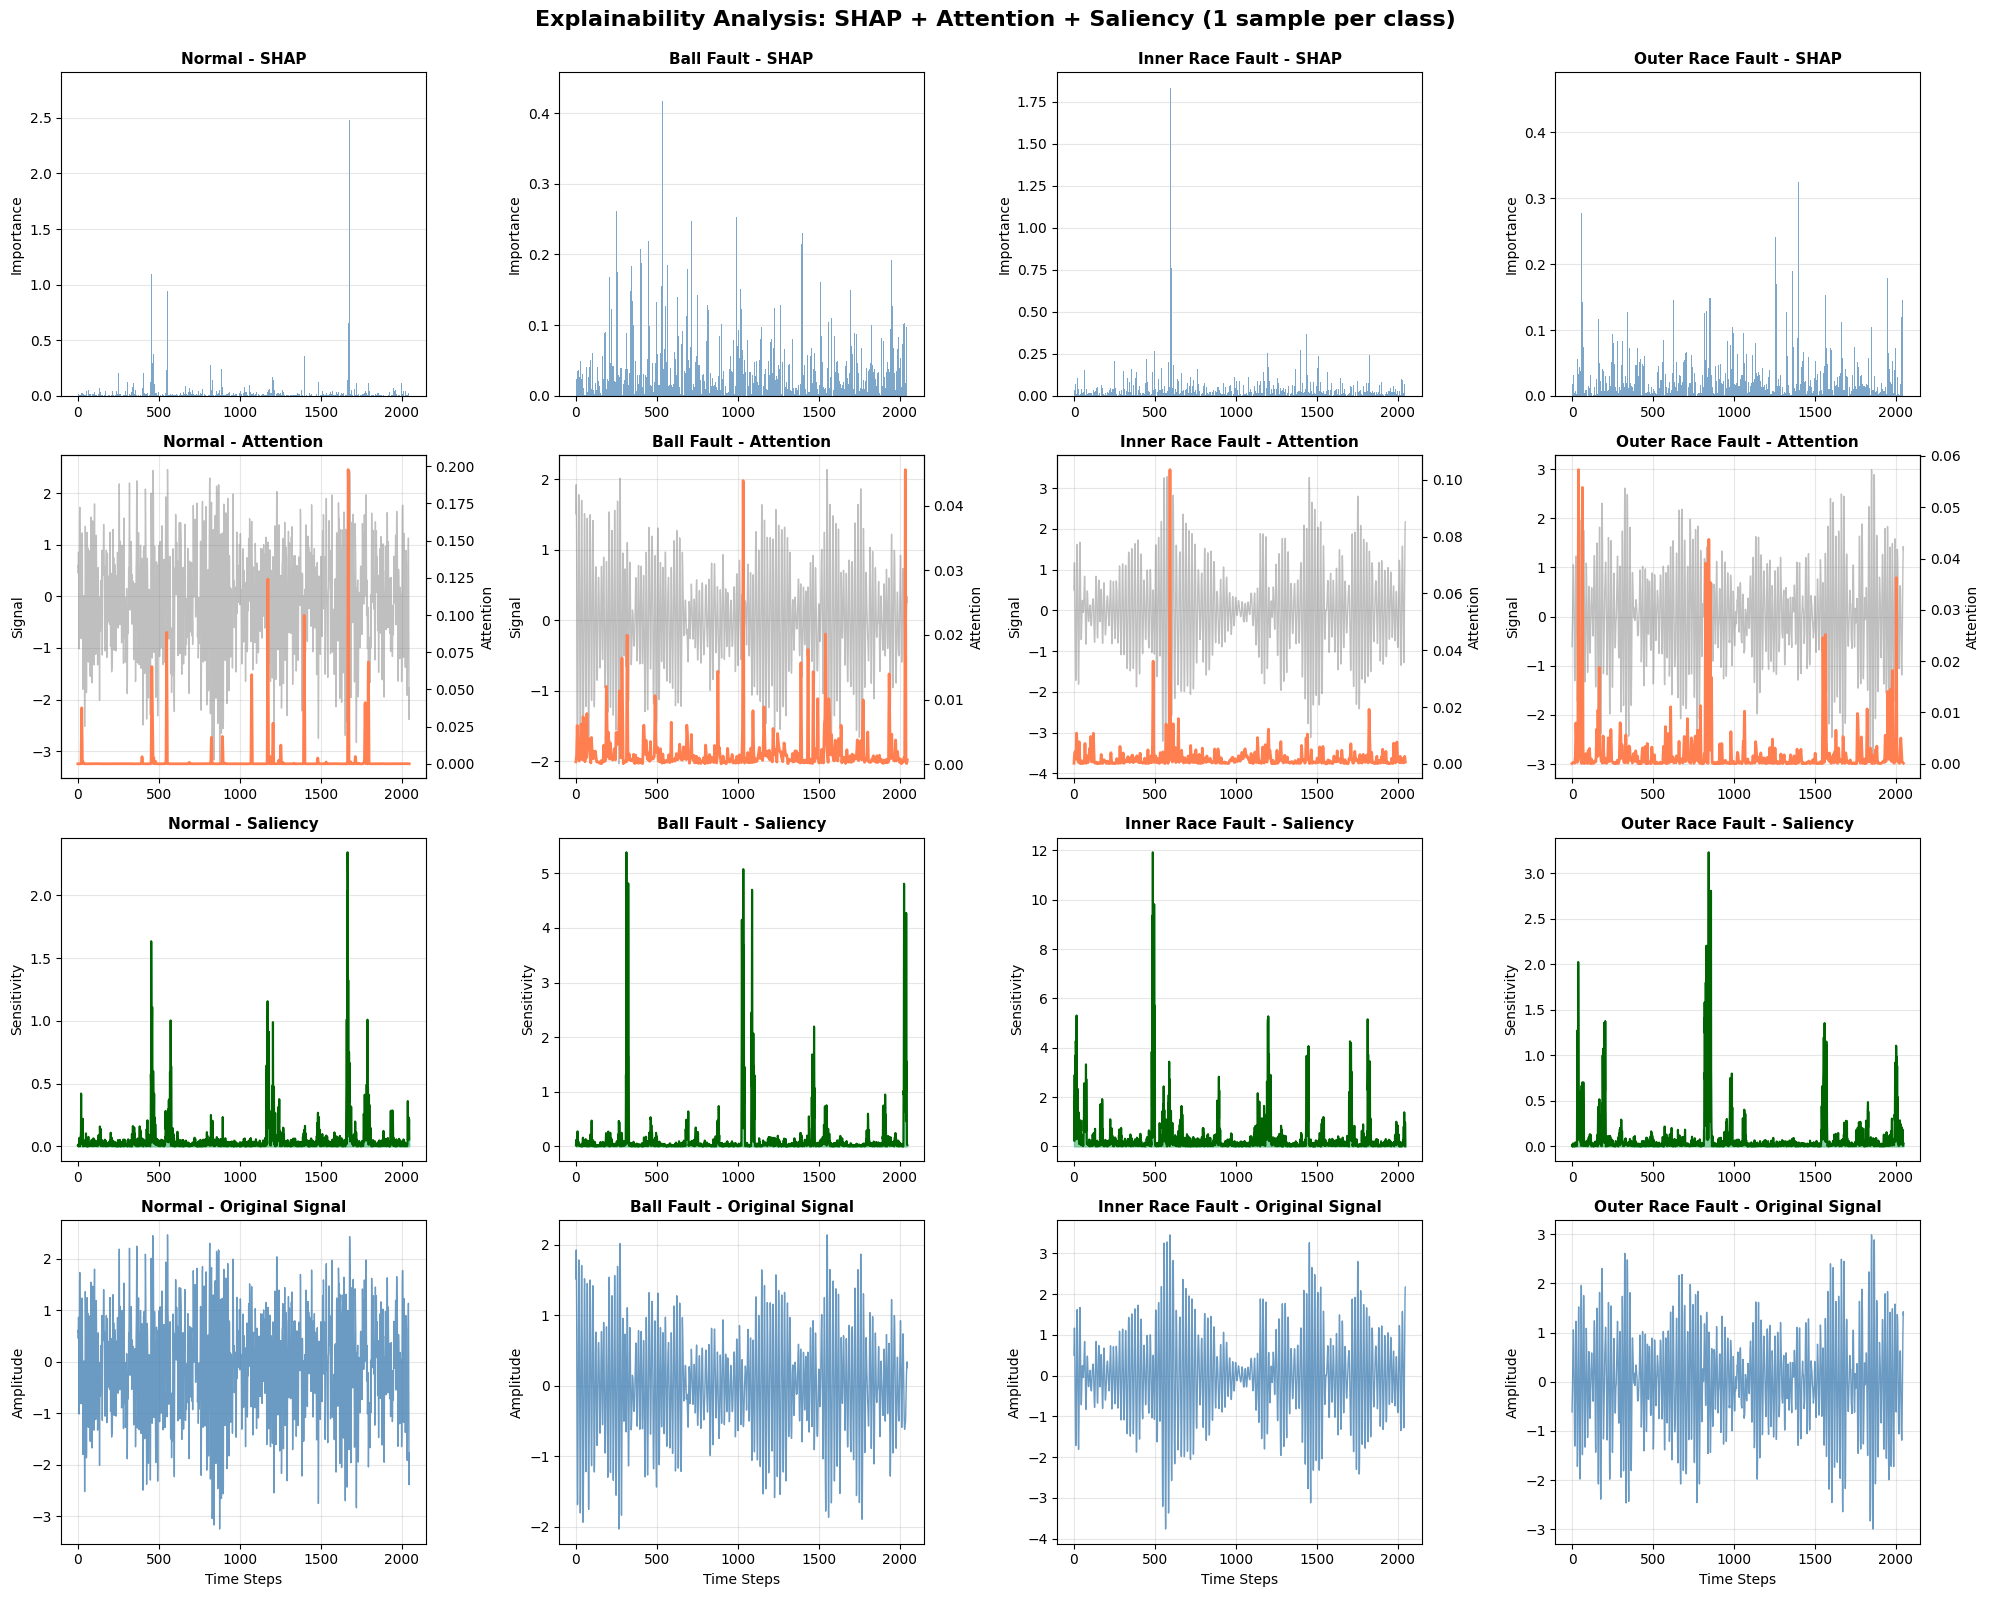


✅ Explainability visualization saved!


In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize all 3 XAI methods
fig = plt.figure(figsize=(20, 16)) # Adjusted figsize for 4x4 grid
fig.suptitle('Explainability Analysis: SHAP + Attention + Saliency (1 sample per class)',
             fontsize=16, fontweight='bold', y=0.995)

for class_id in range(NUM_CLASSES):
    if class_id in sample_indices_shap:
        sample_idx = sample_indices_shap[class_id]
        signal = X_test_scaled[sample_idx]

        # SHAP
        ax1 = plt.subplot(4, NUM_CLASSES, class_id + 1) # Changed 3 to NUM_CLASSES
        if class_id in shap_values_all and shap_values_all[class_id] is not None:
            # SHAP values are structured as [output_idx, batch_idx, features]
            # We're interested in the SHAP values for the predicted class
            # and only the first batch item (since we're passing one sample)
            # Correctly select the SHAP values for the specific class_id to be plotted
            shap_vals_for_class = shap_values_all[class_id][0, 0, :, class_id]

            # Ensure shap_vals_for_class has the correct length before flattening
            if len(shap_vals_for_class) == len(signal):
                # For plotting, take absolute values to show magnitude of importance
                ax1.bar(range(len(signal)), np.abs(shap_vals_for_class), color='steelblue', alpha=0.7, width=1)
            ax1.set_title(f'{CLASS_NAMES[class_id]} - SHAP', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Importance', fontsize=10)
        ax1.grid(True, alpha=0.3, axis='y')

        # Attention
        ax2 = plt.subplot(4, NUM_CLASSES, class_id + NUM_CLASSES + 1) # Changed 3 to NUM_CLASSES

        if class_id in attention_weights_all:

            attn = attention_weights_all[class_id]

            # Handle attention weights
            if attn.ndim == 4:
                # (batch, heads, seq_len, seq_len)
                attn_avg = attn.mean(axis=(0, 1))

            elif attn.ndim == 3:
                # (batch, seq_len, seq_len)
                attn_avg = attn.mean(axis=0)

            else:
                # If already averaged to (seq_len, seq_len) or (seq_len,)
                attn_avg = attn

            # Convert attention matrix -> temporal importance (average across attended positions)
            if attn_avg.ndim == 2:
                attn_avg = attn_avg.mean(axis=0)

            # Resize from 512 -> 2048
            attn_avg = np.interp(
                np.linspace(0, len(attn_avg)-1, len(signal)),
                np.arange(len(attn_avg)),
                attn_avg
            )

            ax2.plot(signal,
                     linewidth=1,
                     alpha=0.5,
                     color='gray',
                     label='Signal')

            ax2_twin = ax2.twinx()

            ax2_twin.plot(attn_avg,
                          linewidth=2,
                          color='coral',
                          label='Attention')

            ax2.set_title(f'{CLASS_NAMES[class_id]} - Attention',
                          fontsize=11,
                          fontweight='bold')

            ax2.set_ylabel("Signal", fontsize=10)

            ax2_twin.set_ylabel("Attention", fontsize=10)

        ax2.grid(True, alpha=0.3)

        # Saliency
        ax3 = plt.subplot(4, NUM_CLASSES, class_id + 2*NUM_CLASSES + 1) # Changed 3 to NUM_CLASSES
        if class_id in saliency_maps:
            saliency = saliency_maps[class_id]
            if len(saliency) == len(signal):
                ax3.fill_between(range(len(signal)), saliency, alpha=0.6, color='mediumseagreen')
                ax3.plot(saliency, linewidth=1.5, color='darkgreen')
            ax3.set_title(f'{CLASS_NAMES[class_id]} - Saliency', fontsize=11, fontweight='bold')
            ax3.set_ylabel('Sensitivity', fontsize=10)
        ax3.grid(True, alpha=0.3, axis='y')

        # Original signal (bottom row)
        ax4 = plt.subplot(4, NUM_CLASSES, class_id + 3*NUM_CLASSES + 1) # Changed 3 to NUM_CLASSES
        ax4.plot(signal, linewidth=1, color='steelblue', alpha=0.8)
        ax4.set_title(f'{CLASS_NAMES[class_id]} - Original Signal', fontsize=11, fontweight='bold')
        ax4.set_xlabel('Time Steps', fontsize=10)
        ax4.set_ylabel('Amplitude', fontsize=10)
        ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/explainability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Explainability visualization saved!")

## SECTION 8: PREDICTIONS & SAMPLE ANALYSIS

In [88]:
import numpy as np
# Generate sample predictions with explanations
print("\n" + "="*70)
print("🎯 SAMPLE PREDICTIONS & EXPLANATIONS".center(70))
print("="*70)

predictions_summary = []

for class_id in range(NUM_CLASSES):
    class_indices = np.where(y_test == class_id)[0]
    if len(class_indices) > 0:
        # Select a correctly classified sample
        for idx in class_indices:
            if y_pred[idx] == class_id:
                sample_data = {
                    'class_id': class_id,
                    'class_name': CLASS_NAMES[class_id],
                    'test_idx': idx,
                    'true_label': y_true[idx],
                    'predicted_label': y_pred[idx],
                    'probabilities': y_probs[idx],
                    'confidence': y_probs[idx, class_id],
                    'uncertainty': y_uncertainty[idx],
                    'signal': X_test_scaled[idx]
                }
                predictions_summary.append(sample_data)
                break

print(f"\n📋 Selected {len(predictions_summary)} samples (1 per class, correctly classified):\n")

for sample in predictions_summary:
    class_name = sample['class_name']
    confidence = sample['confidence']
    uncertainty = sample['uncertainty'] # Removed [0] as it's already a scalar

    print(f"🔹 {class_name}")
    print(f"   Predicted: {CLASS_NAMES[sample['predicted_label']]} ✅")
    print(f"   Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"   Uncertainty: {uncertainty:.4f}")

    # Show probabilities for all classes
    print(f"   Class probabilities:")
    for c_id, prob in enumerate(sample['probabilities']):
        bar_length = int(prob * 30)
        print(f"      {CLASS_NAMES[c_id]:<20s}: {prob:.4f} {'█' * bar_length}")
    print()



                 🎯 SAMPLE PREDICTIONS & EXPLANATIONS                  

📋 Selected 4 samples (1 per class, correctly classified):

🔹 Normal
   Predicted: Normal ✅
   Confidence: 1.0000 (100.00%)
   Uncertainty: 0.5000
   Class probabilities:
      Normal              : 1.0000 ██████████████████████████████
      Ball Fault          : 0.0000 
      Inner Race Fault    : 0.0000 
      Outer Race Fault    : 0.0000 

🔹 Ball Fault
   Predicted: Ball Fault ✅
   Confidence: 1.0000 (100.00%)
   Uncertainty: 0.5000
   Class probabilities:
      Normal              : 0.0000 
      Ball Fault          : 1.0000 █████████████████████████████
      Inner Race Fault    : 0.0000 
      Outer Race Fault    : 0.0000 

🔹 Inner Race Fault
   Predicted: Inner Race Fault ✅
   Confidence: 1.0000 (100.00%)
   Uncertainty: 0.4999
   Class probabilities:
      Normal              : 0.0000 
      Ball Fault          : 0.0000 
      Inner Race Fault    : 1.0000 ██████████████████████████████
      Outer Race Fau

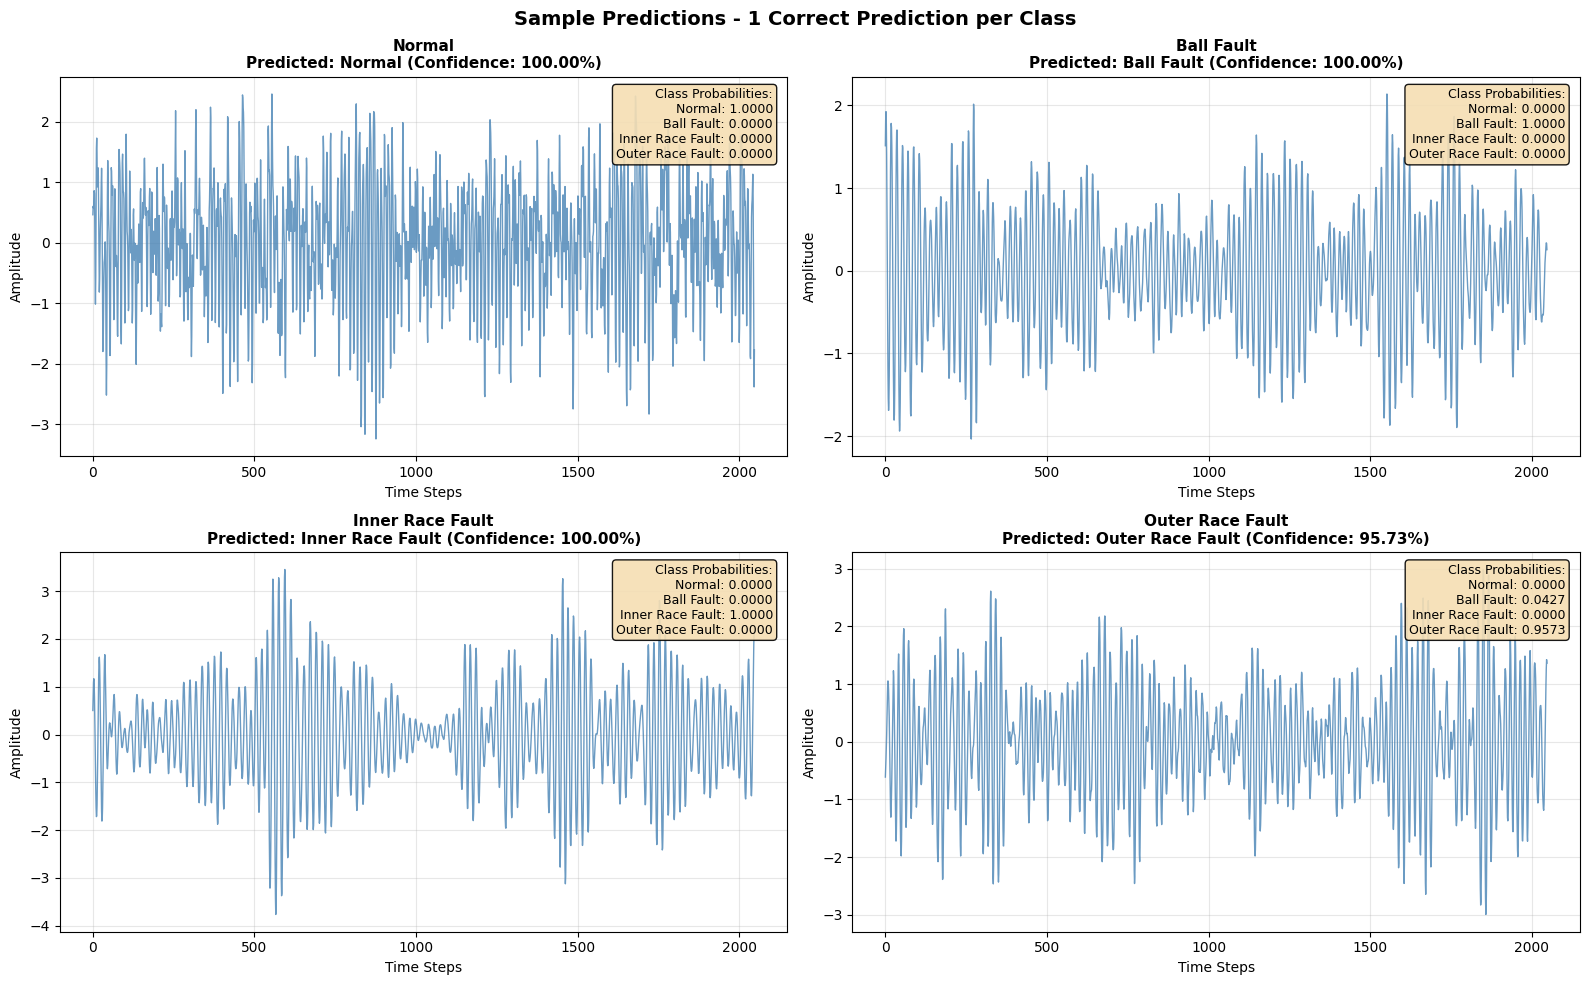

✅ Sample predictions visualization saved!


In [89]:
# Visualize sample predictions with confidence
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Sample Predictions - 1 Correct Prediction per Class', fontsize=14, fontweight='bold')

for plot_idx, sample in enumerate(predictions_summary):
    ax = axes[plot_idx // 2, plot_idx % 2]

    # Plot signal and prediction info
    ax.plot(sample['signal'], linewidth=1, color='steelblue', alpha=0.8, label='Signal')

    # Title with prediction info
    true_class = CLASS_NAMES[sample['true_label']]
    pred_class = CLASS_NAMES[sample['predicted_label']]
    confidence = sample['confidence']

    title = f"{sample['class_name']}\nPredicted: {pred_class} (Confidence: {confidence:.2%})"
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Add text with probabilities
    prob_text = "Class Probabilities:\n" + "\n".join(
        [f"{CLASS_NAMES[i]}: {sample['probabilities'][i]:.4f}"
         for i in range(NUM_CLASSES)]
    )
    ax.text(0.98, 0.97, prob_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sample predictions visualization saved!")

## SECTION 9: SAVE MODEL & ARTIFACTS

In [91]:
print("\n" + "="*70)
print("💾 SAVING MODEL & ARTIFACTS".center(70))
print("="*70)

# Save model
model_path = '/content/prognostix_model.pth'
torch.save(model.state_dict(), model_path)
print(f"\n✅ Model saved: {model_path}")
print(f"   File size: {os.path.getsize(model_path) / 1e6:.2f} MB")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': len(train_losses)
}, '/content/prognostix_checkpoint.pth')

# Save model config
config = {
    'model_type': 'AttentionBearingNet',
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'input_length': X_train_scaled.shape[1],
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test),
    'num_parameters': sum(p.numel() for p in model.parameters()),
    'framework': 'PyTorch 2.0',
    'training_epochs': len(train_losses),
    'best_val_accuracy': float(max(val_accuracies)),
    'test_accuracy': float(overall_accuracy),
    'test_f1_score': float(overall_f1),
    'test_roc_aucs': [float(x) for x in roc_aucs],
    'device': str(device)
}

config_path = '/content/prognostix_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)

print(f"✅ Config saved: {config_path}")

# Save scaler
scaler_path = '/content/prognostix_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✅ Scaler saved: {scaler_path}")


                      💾 SAVING MODEL & ARTIFACTS                      

✅ Model saved: /content/prognostix_model.pth
   File size: 3.06 MB
✅ Config saved: /content/prognostix_config.json
✅ Scaler saved: /content/prognostix_scaler.pkl


In [92]:
print(f"\n💾 Saving sample data for Streamlit app...")

sample_data_dir = '/content/sample_data'
os.makedirs(sample_data_dir, exist_ok=True)

for class_id in range(NUM_CLASSES):
    class_indices = np.where(y_test == class_id)[0]

    if len(class_indices) > 0:
        sample_idx = np.random.choice(class_indices)
        sample_signal = X_test_scaled[sample_idx]

        sample_package = {
            "data": sample_signal,
            "label_id": class_id,
            "label_name": CLASS_NAMES[class_id]
        }

        file_name = f"class_{class_id}_{CLASS_NAMES[class_id].replace(' ', '_').lower()}.pkl"
        sample_file = f"{sample_data_dir}/{file_name}"

        with open(sample_file, 'wb') as f:
            pickle.dump(sample_package, f)

        print(f"   ✅ Saved: {CLASS_NAMES[class_id]}")

print(f"\n✅ Sample data saved to {sample_data_dir}")


💾 Saving sample data for Streamlit app...
   ✅ Saved: Normal
   ✅ Saved: Ball Fault
   ✅ Saved: Inner Race Fault
   ✅ Saved: Outer Race Fault

✅ Sample data saved to /content/sample_data


In [93]:
import numpy as np

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

results_summary = {
    'model_info': {
        'name': 'AttentionBearingNet',
        'framework': 'PyTorch 2.0',
        'architecture': 'CNN + LSTM + MultiheadAttention',
        'total_parameters': int(sum(p.numel() for p in model.parameters())),
        'model_size_mb': round(os.path.getsize(model_path) / 1e6, 2)
    },
    'dataset_info': {
        'source': 'CWRU Bearing Dataset (Kaggle)',
        'num_classes': NUM_CLASSES,
        'class_names': CLASS_NAMES,
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'signal_length': int(X_train_scaled.shape[1])
    },
    'training_info': {
        'num_epochs': len(train_losses),
        'batch_size': BATCH_SIZE,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'device': str(device)
    },
    'performance_metrics': {
        'overall_accuracy': float(overall_accuracy),
        'overall_f1_score': float(overall_f1),
        'per_class_metrics': {}
    },
    'explainability': {
        'methods': ['SHAP', 'Attention', 'Saliency'],
        'shap_status': 'Computed' if 'shap_values_all' in globals() else 'Failed',
        'attention_status': 'Computed',
        'saliency_status': 'Computed'
    }
}

for class_id in range(NUM_CLASSES):
    tp = ((y_pred_np == class_id) & (y_true_np == class_id)).sum()
    fp = ((y_pred_np == class_id) & (y_true_np != class_id)).sum()
    fn = ((y_pred_np != class_id) & (y_true_np == class_id)).sum()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    results_summary['performance_metrics']['per_class_metrics'][CLASS_NAMES[class_id]] = {
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1)
    }

results_path = '/content/results_summary.json'
with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"\n✅ Results summary saved: {results_path}")


✅ Results summary saved: /content/results_summary.json


## FINAL SUMMARY & NEXT STEPS

In [94]:
print("\n" + "="*70)
print("🎉 PROGNOSTIX TRAINING COMPLETE!".center(70))
print("="*70)

print(f"\n📊 FINAL PERFORMANCE REPORT")
print(f"{'-'*70}")

print(f"\nOverall Metrics:")
print(f"  Accuracy:              {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"  F1 Score (weighted):   {overall_f1:.4f}")
print(f"  Average ROC-AUC:       {np.mean(roc_aucs) if len(roc_aucs)>0 else 0:.4f}")

print(f"\nPer-Class Metrics:")

metrics_dict = results_summary.get('performance_metrics', {}).get('per_class_metrics', {})

for class_id in range(NUM_CLASSES):
    class_name = CLASS_NAMES[class_id]
    if class_name in metrics_dict:
        m = metrics_dict[class_name]
        print(f"  {class_name:<20s}: P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1_score']:.4f}")

print(f"\n📁 FILES SAVED:")
print(f"{'-'*70}")
print(f"  ✅ Model:              prognostix_model.pth")
print(f"  ✅ Config:             prognostix_config.json")
print(f"  ✅ Scaler:             prognostix_scaler.pkl")
print(f"  ✅ Results Summary:     results_summary.json")
print(f"  ✅ Sample Data:        sample_data/")
print(f"  ✅ Visualizations:     PNG files")

print(f"\n🎯 NEXT STEPS:")
print(f"{'-'*70}")
print(f"  1. Download artifacts")
print(f"  2. Build Streamlit app")
print(f"  3. Deploy on Streamlit Cloud")
print(f"  4. Share on LinkedIn")

print(f"\n" + "="*70)
print(f"✨ READY FOR DEPLOYMENT".center(70))
print("="*70)


                   🎉 PROGNOSTIX TRAINING COMPLETE!                    

📊 FINAL PERFORMANCE REPORT
----------------------------------------------------------------------

Overall Metrics:
  Accuracy:              0.9808 (98.08%)
  F1 Score (weighted):   0.9808
  Average ROC-AUC:       0.9992

Per-Class Metrics:
  Normal              : P=1.0000, R=1.0000, F1=1.0000
  Ball Fault          : P=0.9626, R=0.9671, F1=0.9649
  Inner Race Fault    : P=1.0000, R=1.0000, F1=1.0000
  Outer Race Fault    : P=0.9670, R=0.9624, F1=0.9647

📁 FILES SAVED:
----------------------------------------------------------------------
  ✅ Model:              prognostix_model.pth
  ✅ Config:             prognostix_config.json
  ✅ Scaler:             prognostix_scaler.pkl
  ✅ Results Summary:     results_summary.json
  ✅ Sample Data:        sample_data/
  ✅ Visualizations:     PNG files

🎯 NEXT STEPS:
----------------------------------------------------------------------
  1. Download artifacts
  2. Build Streaml

In [95]:
# List all files available for download
print("\n📦 FILES READY FOR DOWNLOAD:\n")

download_files = [
    '/content/prognostix_model.pth',
    '/content/prognostix_config.json',
    '/content/prognostix_scaler.pkl',
    '/content/results_summary.json',
    '/content/sample_signals.png',
    '/content/preprocessing_effect.png',
    '/content/adasyn_effect.png',
    '/content/training_curves.png',
    '/content/confusion_matrix.png',
    '/content/roc_curves.png',
    '/content/explainability_analysis.png',
    '/content/sample_predictions.png'
]

for i, file_path in enumerate(download_files, 1):
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        file_name = os.path.basename(file_path)

        if file_size < 1e6:
            size_str = f"{file_size/1e3:.1f} KB"
        else:
            size_str = f"{file_size/1e6:.1f} MB"

        print(f"{i:2d}. ✅ {file_name:<35s} ({size_str})")

print(f"\nSample data files:")
for filename in os.listdir('/content/sample_data'):
    file_path = os.path.join('/content/sample_data', filename)
    file_size = os.path.getsize(file_path)
    print(f"     ✅ {filename:<35s} ({file_size/1e3:.1f} KB)")

print(f"\n💡 TIP: Click the folder icon on the left sidebar to download files directly!")


📦 FILES READY FOR DOWNLOAD:

 1. ✅ prognostix_model.pth                (3.1 MB)
 2. ✅ prognostix_config.json              (0.6 KB)
 3. ✅ prognostix_scaler.pkl               (49.6 KB)
 4. ✅ results_summary.json                (1.8 KB)
 7. ✅ adasyn_effect.png                   (51.0 KB)
 8. ✅ training_curves.png                 (137.8 KB)
 9. ✅ confusion_matrix.png                (62.9 KB)
10. ✅ roc_curves.png                      (179.9 KB)
11. ✅ explainability_analysis.png         (731.5 KB)
12. ✅ sample_predictions.png              (728.5 KB)

Sample data files:
     ✅ anscombe.json                       (1.7 KB)
     ✅ README.md                           (1.0 KB)
     ✅ class_0_normal.pkl                  (8.4 KB)
     ✅ class_1_ball_fault.pkl              (8.4 KB)
     ✅ class_3_outer_race_fault.pkl        (8.4 KB)
     ✅ class_2_inner_race_fault.pkl        (8.4 KB)
     ✅ mnist_train_small.csv               (36523.9 KB)
     ✅ california_housing_test.csv         (301.1 KB)
     ✅ 

In [96]:
from google.colab import files

files.download('/content/prognostix_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
import shutil

shutil.make_archive('/content/sample_data', 'zip', '/content/sample_data')

'/content/sample_data.zip'

In [98]:
files.download('/content/sample_data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
files.download('/content/prognostix_config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
files.download('/content/prognostix_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [101]:
files.download('/content/results_summary.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>